## main code

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os

NUCLEOTIDES = ['A', 'C', 'G', 'T']
NUC_TO_IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
WINDOW_SIZES = [30, 35,36,37,38,39,40]
    ''' the length of the window was deduced by trial and error, starting from 20 up to 140;
        the scores lower than 30 didn't add any value to the results, so they were omitted;
        a linear growth of the score could be observed with the widening of the window however from a biologial perspective a larger window doesnt signify more generelisable results;
        biologial motifs usulally operate within the 15-40 residue distance, but indroducing windows larger than that introduces non-local noise
    '''

FILE_PATH = "/content/"
# gdzie znajduja sie pliki z modelami, validation.py i sekwencjami
OUT_DIR = "runs_stochastic"
# gdzie powinny pojawic sie wyniki analizy

if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)

def one_hot_encode(seq: str) -> torch.Tensor:
    ohe = torch.zeros((4, len(seq)), dtype=torch.float32)
    for i, char in enumerate(seq.upper()):
        if char in NUC_TO_IDX:
            ohe[NUC_TO_IDX[char], i] = 1.0
    return ohe.to(device)

def one_hot_decode(tensor: torch.Tensor) -> str:
    """z one do prawdziwej sekwencji"""
    indices = torch.argmax(tensor, dim=0)
    return "".join([NUCLEOTIDES[idx.item()] for idx in indices])


In [ ]:
def evaluate_single_model(input_tensor: torch.Tensor, model: nn.Module) -> torch.Tensor:
    """
    funkcja ocenia rna_dna_ratio dla podanej sekwencji;
    jest to dosstowoane w zaleznosci od modelu, ktory byl wykorzystywany do znaleznienia tej sekwencji
    """

    model_name = type(model).__name__
    model_device = next(model.parameters()).device
    x = input_tensor.unsqueeze(0).to(model_device)

    with torch.set_grad_enabled(True):
        predicted = model(x)

    # --- A (DeepSTARR) ---
    if model_name == "DeepSTARR":
        _, ratio_norm = predicted if isinstance(predicted, tuple) else (None, predicted)
        # dane sa normalizowane, by uzyskac prawdziwe wartosci trzeba 'odnormalizowac'
        train_mean = -0.22148310042248945
        train_std = 0.7843937844681367
        output_real = ratio_norm * train_std + train_mean
        return output_real.squeeze()

    # --- J (DeepSTARR_Lite) ---
    elif model_name == "DeepSTARR_Lite":
        _, out_reg = predicted if isinstance(predicted, tuple) else (None, predicted)
        return out_reg.squeeze()

    # --- M (DNARegulatoryCNN) ---
    elif model_name == "DNARegulatoryCNN":
        _, reg_scaled = predicted if isinstance(predicted, tuple) else (None, predicted)
        # dane znormalizowane
        reg_mean = float(getattr(model, "reg_mean", 0.0))
        reg_std = float(getattr(model, "reg_std", 1.0))
        if hasattr(model, "_reg_stats"):
            reg_mean, reg_std = model._reg_stats
            reg_mean = float(reg_mean)
            reg_std = float(reg_std)
        output_real = reg_scaled * reg_std + reg_mean
        # dane odnormalizowane
        return output_real.squeeze()

    else:
        pred = predicted[1] if isinstance(predicted, tuple) and len(predicted) > 1 else predicted
        return pred.squeeze()



In [ ]:
def optimize_sequence_single(initial_seq: str, model: nn.Module, max_iterations: int = 50, scan_window_size: int = 10, device=None):
    """
    optymalizacja sekwencji korzystajac z gradient attribution i in silico scanning
    idea: wykorzystujac backpropagation identyfikujemy pozycje o najwiekszej wrazliwosci, posrod nich wybieramy z pewnym prawdopodobienstwem pozycje.
          pozycja owa bedzie srodkiem in silico scanning, ktory w rejonie o wielkosci window bedzie analizowac potencjalne mutacje i ich impact na score sekwencji.
          biologicznie patrząc, mutacje rzadko wystepuja w calkowitej izolacji, wiec pozycje o wysokiej wrazliwosci wskazuja, ze w ich otoczeniu jest duza szansa na mutacje, ktore ulepsza sekwencje.
          pozwala to uniknac skanowania calej sekwencji.
          o ile pierwsza pozycje wybieramy nie deterministycznie to juz mutacje, ktora wprowadzamy do sekwencji zawsze wybieramy ta z najwieksza roznica w score sekwencji
    """
    model.to(device)
    current_tensor = one_hot_encode(initial_seq)

    optimization_history = []

    print(f"Initial Sequence Length: {current_tensor.shape[1]} bp")

    for iteration in range(1, max_iterations + 1):
        print(f"\n--- BEGIN ITERATION {iteration:03d} ---")
        #saliency scanning
        current_tensor.requires_grad = True
        current_score_tensor = evaluate_single_model(current_tensor, model)
        baseline_score = current_score_tensor.item()

        print(f"[BASE EVAL] Current Sequence Predicted Real Ratio: {baseline_score:.6f}")

        # backpropagation to find nt sensitivity
        # nt sensistivity = gradient of the score with respect to the nt; tells us how much the score will change if we change the nt
        model.zero_grad()
        if current_tensor.grad is not None:
            current_tensor.grad.zero_()
        current_score_tensor.backward()
        gradients = current_tensor.grad

        ''' majac wartosci gradientow, bedziemy stochatycznie wybierac jeden z pięciu (pool_size) najwrazliwszych meijsc w sekwencji = takie gdzie zmiana nt powinna najbardziej wplynac na wynik modelu;
            ta pozycja dziala jak kotwica, wokol ktorej bedziemy 'in silico skanowac' otoczenie probujac wszystkich mozliwosci nt dla danych pozycji zeby znalezc zmiane o najwiekszym potencjale poprawy sekwencji;
            pozwala to zachowac element losowosci i nie utknac w lokalnym optimum
        '''

        # choosing the anchor
        position_sensitivity = torch.max(torch.abs(gradients), dim=0)[0]

        pool_size = 5
        top_candidate_anchors = torch.topk(position_sensitivity, k=pool_size).indices.cpu().numpy()

        raw_candidate_sensitivity = position_sensitivity[top_candidate_anchors]

        probabilities = torch.softmax(raw_candidate_sensitivity, dim=0).cpu().numpy()

        chosen_anchor = int(np.random.choice(top_candidate_anchors, p=probabilities))

        half_win = scan_window_size // 2
        window_start = max(0, chosen_anchor - half_win)
        window_end = min(230, chosen_anchor + half_win)

        window_positions = list(range(window_start, window_end))

        print(f"[SALIENCY] Global Max Gradient Magnitude: {torch.max(position_salience).item():.6f}")
        print(f"[SALIENCY] High-Sensitivity Anchor Candidates: {top_candidate_anchors}")
        print(f"[WINDOW] Stochastically Anchored Window at bp {chosen_anchor}")
        print(f"[WINDOW] Contiguous Footprint (bp {window_start} to {window_end - 1}): {window_positions}")

        best_mutation_score = baseline_score
        best_tensor = current_tensor.detach().clone()
        chosen_mutation = None

        # in silico scanning
        print(f"\n[TIER 1] Launching Localized In Silico Scan on Top Positions...")
        current_tensor_detached = current_tensor.detach().clone()
        for pos in window_positions:
            current_base_idx = torch.argmax(current_tensor_detached[:, pos]).item()

            pos_trace = []

            for alt_idx in range(4):
                wt_type = NUCLEOTIDES[current_base_idx]
                alt_type = NUCLEOTIDES[alt_idx]
                if alt_idx == current_base_idx:
                    continue

                mutated_tensor = current_tensor_detached.clone()
                mutated_tensor[:, pos] = 0.0
                mutated_tensor[alt_idx, pos] = 1.0

                with torch.no_grad():
                    variant_score = evaluate_single_model(mutated_tensor, model).item()

                delta = variant_score - baseline_score
                pos_trace.append(f"{alt_type}: {variant_score:.4f} (Δ:{delta:+.4f})")

                if variant_score > best_mutation_score:
                    best_mutation_score = variant_score
                    best_tensor = mutated_tensor.clone()
                    chosen_mutation = {
                        "position": pos,
                        "from": NUCLEOTIDES[current_base_idx],
                        "to": NUCLEOTIDES[alt_idx]
                    }
        if chosen_mutation is not None:
            current_tensor = best_tensor.clone()
            current_seq_str = one_hot_decode(current_tensor)

            optimization_history.append({
                "iteration": iteration,
                "score": best_mutation_score,
                "sequence": current_seq_str,
                "mutation": f"{chosen_mutation['from']}{chosen_mutation['position']}{chosen_mutation['to']}"
            })
            print(f"Iteration {iteration:03d} | Score: {best_mutation_score:.4f} | Mutation: {optimization_history[-1]['mutation']}")
        else:
            print(f"Iteration {iteration:03d} | Convergence reached. No single-model optimization observed.")
            break

    return optimization_history


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

'''
    testowane dla kazdego z sekwencji nalezy odkomentowac jeden z czterech ponizszych kodow, od razu wprowadzane sa ograniczenia co do ilosci mutacji mozliwych dla danej sekwencji (o ile byly podane)
    kazda sekwencja optymalizowana jest przez wszystkie trzy modele dosstepne nam i wyniki sa odpowiednio zapisywane
'''

# with open(FILE_PATH + "seq1.fa", 'r') as f:
#     # og: ~2.5 40 mutations
#     og = 2.5
#     limit=40
#     lines = [line.strip() for line in f if line.strip()]
#     header = lines[0][1:] if lines[0].startswith('>') else ''
#     input_sequence = ''.join(lines[1:]) if len(lines) > 1 else ''


# with open(FILE_PATH + "seq2.fa", 'r') as f:
#     # og: ~2.7 16 mutations
#     og = 2.7
#     limit=16
#     lines = [line.strip() for line in f if line.strip()]
#     header = lines[0][1:] if lines[0].startswith('>') else ''
#     input_sequence = ''.join(lines[1:]) if len(lines) > 1 else ''

with open(FILE_PATH + "seq3.fa", 'r') as f:
    # og: ~1.1 20 mutations
    og = 1.1
    limit=20
    lines = [line.strip() for line in f if line.strip()]
    header = lines[0][1:] if lines[0].startswith('>') else ''
    input_sequence = ''.join(lines[1:]) if len(lines) > 1 else ''

# with open(FILE_PATH + "seq4.fa", 'r') as f:
#     # none
#     limit=None
#     lines = [line.strip() for line in f if line.strip()]
#     header = lines[0][1:] if lines[0].startswith('>') else ''
#     input_sequence = ''.join(lines[1:]) if len(lines) > 1 else ''

seq_len = 230
max_iter = limit if limit is not None else 43

from evaluation_script_A import DeepSTARR
from evaluation_script_J import DeepSTARR_Lite
from evaluation_script_M import DNARegulatoryCNN, get_model_params

for scan_window_size in WINDOW_SIZES:

    # A model
    my_model = DeepSTARR(seq_len)
    my_model.load_state_dict(torch.load(FILE_PATH + "model_A.pth", map_location=device))
    my_model.to(device)
    my_model.eval()

    log_data = optimize_sequence_single(input_sequence, my_model, max_iterations=max_iter, scan_window_size=scan_window_size, device=device)

    if log_data and 'sequence' in log_data[-1]:
        final_mutated_sequence = log_data[-1]['sequence']
        print("Final mutated sequence:", final_mutated_sequence)
    else:
        final_mutated_sequence = None
        print("No mutated sequence found.")
    import datetime

    df_single_trajectory_A = pd.DataFrame(log_data)

    now = datetime.datetime.now()
    time_stamp = now.strftime("%Y%m%d_%H%M%S")
    filename_A = f"{OUT_DIR}/{header}_{time_stamp}_iter{max_iter}_win{scan_window_size}_A.tsv"

    # J model
    my_model_J = DeepSTARR_Lite(seq_len)
    my_model_J.load_state_dict(torch.load(FILE_PATH + "model_J.pth", map_location=device))
    my_model_J.to(device)
    my_model_J.eval()

    log_data_J = optimize_sequence_single(input_sequence, my_model_J, max_iterations=max_iter, scan_window_size=scan_window_size, device=device)

    if log_data_J and 'sequence' in log_data_J[-1]:
        final_mutated_sequence_J = log_data_J[-1]['sequence']
        print("Final mutated sequence:", final_mutated_sequence_J)
    else:
        final_mutated_sequence_J = None
        print("No mutated sequence found.")

    df_single_trajectory_J = pd.DataFrame(log_data_J)

    filename_J = f"{OUT_DIR}/{header}_{time_stamp}_iter{max_iter}_win{scan_window_size}_J.tsv"

    # M model
    # it requires preprocessing
    model_m_ckpt_path = FILE_PATH + "model_M.pth"
    checkpoint_M = torch.load(model_m_ckpt_path, map_location=device)
    try:
        model_params_M = get_model_params(checkpoint_M)
    except Exception as e:
        print("Could not extract model parameters from model_M checkpoint:", e)
        raise
    my_model_M = DNARegulatoryCNN(model_params_M)
    my_model_M.load_state_dict(checkpoint_M["model_state"])
    my_model_M.to(device)
    my_model_M.eval()

    log_data_M = optimize_sequence_single(input_sequence, my_model_M, max_iterations=max_iter, scan_window_size=scan_window_size, device=device)

    if log_data_M and 'sequence' in log_data_M[-1]:
        final_mutated_sequence_M = log_data_M[-1]['sequence']
        print("Final mutated sequence:", final_mutated_sequence_M)
    else:
        final_mutated_sequence_M = None
        print("No mutated sequence found.")

    df_single_trajectory_M = pd.DataFrame(log_data_M)

    filename_M = f"{OUT_DIR}/{header}_{time_stamp}_iter{max_iter}_win{scan_window_size}_M.tsv"

    # save results
    df_single_trajectory_A.to_csv(filename_A, sep='\t', index=False)
    print(f"Saved optimization log to {filename_A}")
    df_single_trajectory_J.to_csv(filename_J, sep='\t', index=False)
    print(f"Saved optimization log to {filename_J}")
    df_single_trajectory_M.to_csv(filename_M, sep='\t', index=False)
    print(f"Saved optimization log to {filename_M}")


this proceedure generated a multitude of files, so to choose the best sequence we plotted the data in various ways to find the best.

## plots: mutation count and cumulative impact on the score

idea: plot the
- number of mutations at a given position (irrelevant of what type of mutation it is - this includes reversal mutation) and
- the cumulative impact of the mutations at this position on the improving of the score (all changes in the score logged by the mutations at this position are summed up = high values mean that changes in this position are good )

### code

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

DATA_DIRECTORY = "runs_stochastic/"
OUTPUT_DIRECTORY = DATA_DIRECTORY + "plots/"
os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)

In [ ]:
def get_seq_hierarchical_grouped_files_from_subfolders(base_dir):
    seq_dict = {}
    for entry in os.listdir(base_dir):
        subfolder_path = os.path.join(base_dir, entry)
        if os.path.isdir(subfolder_path) and entry.startswith("seq_"):
            seq_prefix = entry
            group_dict = {"J": [], "M": [], "A": []}

            files = glob.glob(os.path.join(subfolder_path, "*.tsv")) + glob.glob(os.path.join(subfolder_path, "*.csv"))
            for file_path in files:
                basename = os.path.basename(file_path)

                if basename.endswith("_J.tsv") or basename.endswith("_J.csv"):
                    group_dict["J"].append(file_path)
                elif basename.endswith("_M.tsv") or basename.endswith("_M.csv"):
                    group_dict["M"].append(file_path)
                elif basename.endswith("_A.tsv") or basename.endswith("_A.csv") or \
                    (not (basename.endswith("_J.tsv") or basename.endswith("_M.tsv") or basename.endswith("_J.csv") or basename.endswith("_M.csv"))):
                    group_dict["A"].append(file_path)
            seq_dict[seq_prefix] = group_dict
    return seq_dict

def load_mutations(files):
    all_mutations = []
    for file_path in files:
        try:
            df = pd.read_csv(file_path, sep=None, engine="python")
            df["delta"] = df["score"].diff()
            for _, row in df.iterrows():
                mut_str = str(row["mutation"])
                m = re.match(r"([ACGT])(\d+)([ACGT])", mut_str)
                if m:
                    start, pos, end = m.group(1), int(m.group(2)), m.group(3)
                    all_mutations.append({
                        "position": pos,
                        "mutation": mut_str,
                        "from_nt": start,
                        "to_nt": end,
                        "delta": row["delta"] if not pd.isna(row["delta"]) else 0.0,
                    })
        except Exception as e:
            print(f"[WARNING] Could not process {file_path}: {e}")
    return pd.DataFrame(all_mutations)

def print_mutation_counts(df, group_name):
    """
    Print out count for each position in ranked order for debug/troubleshooting.
    """
    if df.empty:
        print(f"[SKIP] No mutations for {group_name} (nothing to count)")
        return
    counts = df['position'].value_counts()
    print(f"--- Mutation position counts for {group_name} ---")
    for pos, count in counts.items():
        print(f"Position {pos}: {count}")
    print("-------------------------------")

def plot_mutation_bars_and_export_csv(df, group_name, out_dir="plots"):
    stats = df.groupby("position").agg(
        mutation_count=("mutation", "count"),
        cumulative_impact=("delta", "sum")
    ).reset_index()

    def get_common_change(subdf):
        change_counts = subdf.groupby(['from_nt', 'to_nt']).size().reset_index(name='count')
        if change_counts.empty:
            return ""
        top_row = change_counts.loc[change_counts['count'].idxmax()]
        return f"{top_row['from_nt']}→{top_row['to_nt']}"

    common_changes = (
        df.groupby("position")
          .apply(get_common_change)
          .rename("most_common_change")
          .reset_index()
    )
    stats = stats.merge(common_changes, on="position", how="left")

    os.makedirs(out_dir, exist_ok=True)
    stats_csv_path = os.path.join(out_dir, f"{group_name}_mutation_stats.csv")
    stats.to_csv(stats_csv_path, index=False)
    print(f"[SAVED] {stats_csv_path}")

    # (bar plot for mutation frequency, line plot for cumulative delta)
    global seq_len
    seq_len = 230
    if 'seq_len' in globals():
        seq_len = globals()['seq_len']

    sns.set_theme(style="whitegrid")

    positions_full = np.arange(seq_len)
    mutation_count_full = np.zeros(seq_len, dtype=int)
    mutation_dict = dict(zip(stats['position'], stats['mutation_count']))

    for i in positions_full:
        mutation_count_full[i] = mutation_dict.get(i, 0)

    cumulative_impact_full = np.zeros(seq_len)
    impact_dict = dict(zip(stats['position'], stats['cumulative_impact']))
    for i in positions_full:
        cumulative_impact_full[i] = impact_dict.get(i, 0)

    plt.figure(figsize=(14, 8))
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    ax1.bar(
        positions_full,
        mutation_count_full,
        width=1.0,
        color='royalblue',
        alpha=0.6,
        label='Mutation Frequency'
    )

    ax2.plot(
        positions_full,
        cumulative_impact_full,
        color='crimson',
        linewidth=2,
        marker='o',
        markersize=3,
        label='Cumulative Δ Impact'
    )

    ax1.set_xlabel('Sequence Coordinate Position (bp)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Total Frequency of Mutations Across Runs', color='royalblue', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Cumulative Score Delta ($\\sum \\Delta$)', color='crimson', fontsize=12, fontweight='bold')

    # Set ticks
    tick_spacing = 10
    ax1.set_xticks(range(0, seq_len, tick_spacing))
    ax1.set_xticklabels(range(0, seq_len, tick_spacing), rotation=45, fontsize=11)
    ax1.set_xlim(-1, seq_len)

    # Add vertical grid lines every tick_spacing
    for x in range(0, seq_len, tick_spacing):
        ax1.axvline(x=x, color='grey', linestyle='--', alpha=0.38, linewidth=1, zorder=0)

    # Title
    plt.title(f'Genomic Hotspot Analysis: Positional Mapping of Engineered Mutations ({group_name})',
              fontsize=14, fontweight='bold', pad=15)

    # Legends
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    if handles1:
        ax1.legend(handles1, labels1, loc='upper left', fontsize=12, frameon=True)
    if handles2:
        ax2.legend(handles2, labels2, loc='upper right', fontsize=12, frameon=True)

    plt.tight_layout()
    out_path = os.path.join(out_dir, f"{group_name}_mutation_impact_bars.png")
    plt.savefig(out_path, dpi=300)
    plt.close()
    print(f"[SAVED] {out_path}")

if __name__ == "__main__":
    seq_group_dict = get_seq_hierarchical_grouped_files_from_subfolders(DATA_DIRECTORY)
    seq_len = 230
    for seq_name, group_dict in seq_group_dict.items():
        for group_name, files in group_dict.items():
            if not files:
                print(f"[SKIP] No files for {seq_name}/{group_name}")
                continue
            df = load_mutations(files)
            if df.empty:
                print(f"[SKIP] No mutations for {seq_name}/{group_name}")
                continue
            # print_mutation_counts(df, f"{seq_name}_{group_name}")
            # Create sub-directory for plots by seq group
            out_dir = os.path.join(OUTPUT_DIRECTORY, seq_name)
            plot_mutation_bars_and_export_csv(df, f"{seq_name}_{group_name}", out_dir=out_dir)


[SAVED] runs_stochastic/plots/seq_1/seq_1_J_mutation_stats.csv
[SAVED] runs_stochastic/plots/seq_1/seq_1_J_mutation_impact_bars.png
[SAVED] runs_stochastic/plots/seq_1/seq_1_M_mutation_stats.csv
[SAVED] runs_stochastic/plots/seq_1/seq_1_M_mutation_impact_bars.png
[SAVED] runs_stochastic/plots/seq_1/seq_1_A_mutation_stats.csv
[SAVED] runs_stochastic/plots/seq_1/seq_1_A_mutation_impact_bars.png
[SAVED] runs_stochastic/plots/seq_2/seq_2_J_mutation_stats.csv
[SAVED] runs_stochastic/plots/seq_2/seq_2_J_mutation_impact_bars.png
[SAVED] runs_stochastic/plots/seq_2/seq_2_M_mutation_stats.csv
[SAVED] runs_stochastic/plots/seq_2/seq_2_M_mutation_impact_bars.png
[SAVED] runs_stochastic/plots/seq_2/seq_2_A_mutation_stats.csv
[SAVED] runs_stochastic/plots/seq_2/seq_2_A_mutation_impact_bars.png
[SAVED] runs_stochastic/plots/seq_3/seq_3_J_mutation_stats.csv
[SAVED] runs_stochastic/plots/seq_3/seq_3_J_mutation_impact_bars.png
[SAVED] runs_stochastic/plots/seq_3/seq_3_M_mutation_stats.csv
[SAVED] runs_

### seq 1

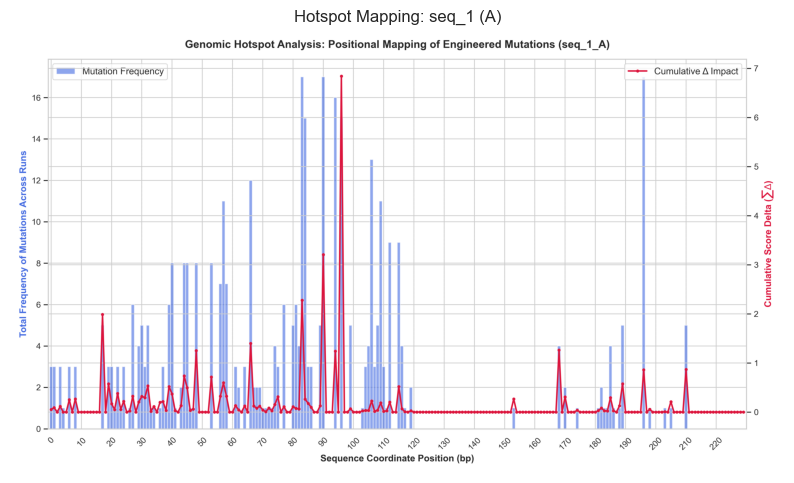

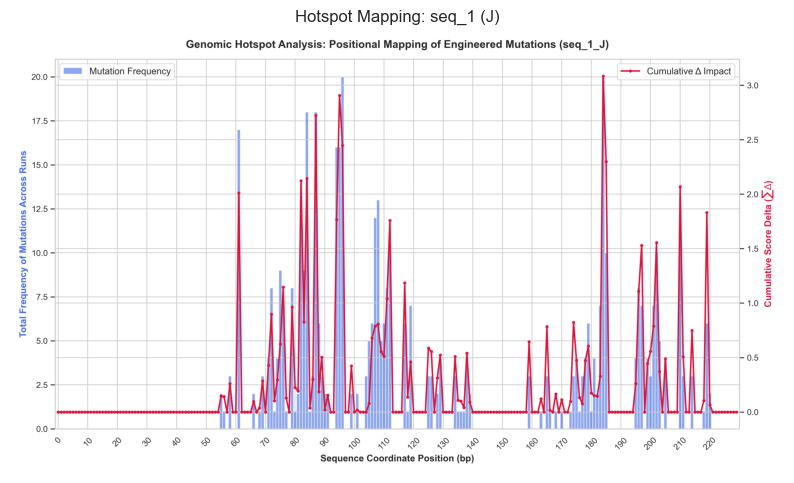

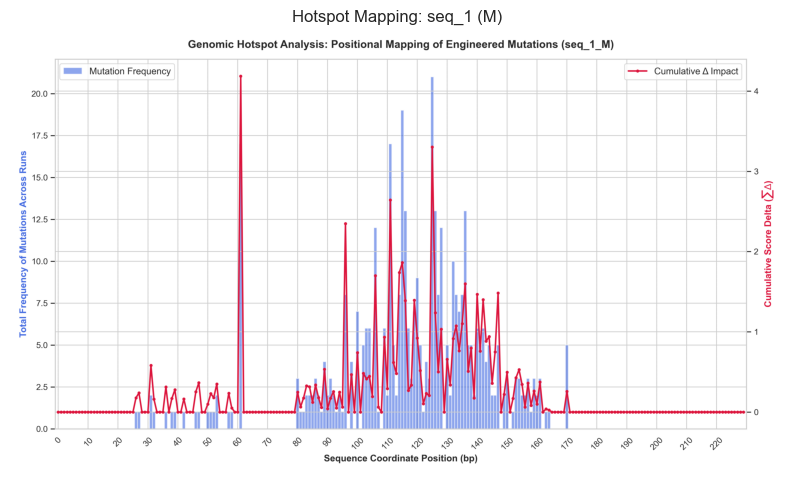

In [ ]:
SEQ_NAME = "seq_1"
OUTPUT_DIRECTORY = "./runs_stochastic/plots/" + SEQ_NAME
MODEL_SUFFIXES = ["A", "J", "M"]

for suffix in MODEL_SUFFIXES:
    hotspot_model_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{suffix}_mutation_impact_bars.png")
    if os.path.exists(hotspot_model_path):
        img = Image.open(hotspot_model_path)
        plt.figure(figsize=(10,6))
        plt.axis('off')
        plt.title(f"Hotspot Mapping: {SEQ_NAME} ({suffix})")
        plt.imshow(img)
        plt.show()
    else:
        print(f"Plot file not found: {hotspot_model_path}")

### seq 2

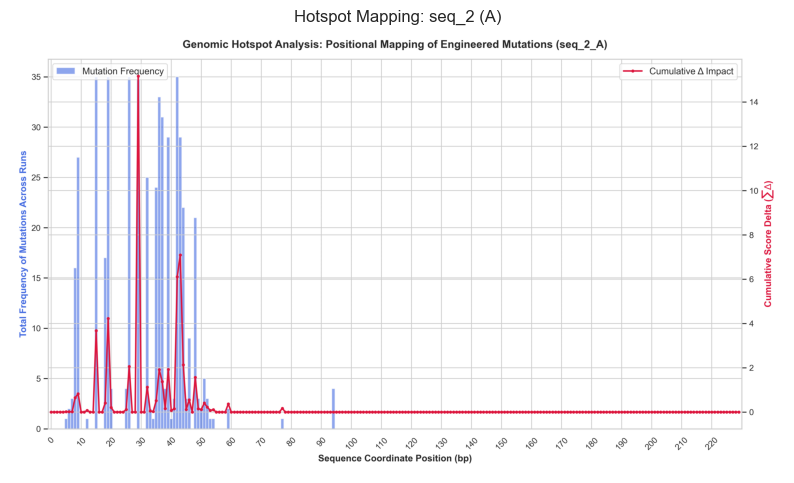

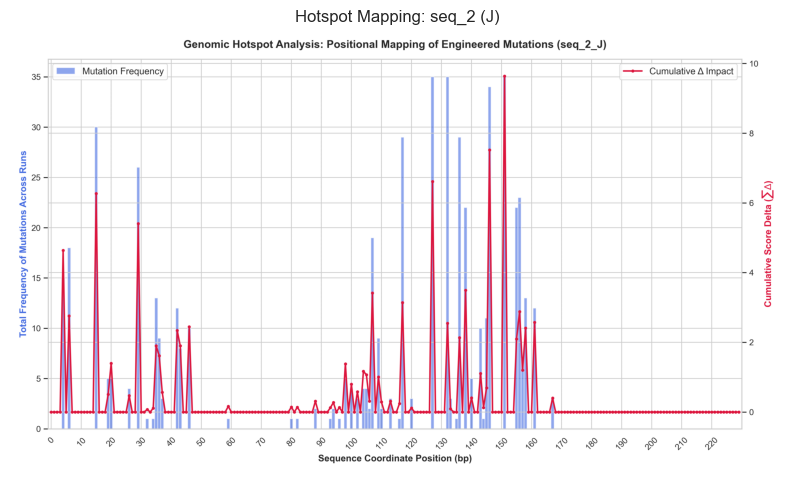

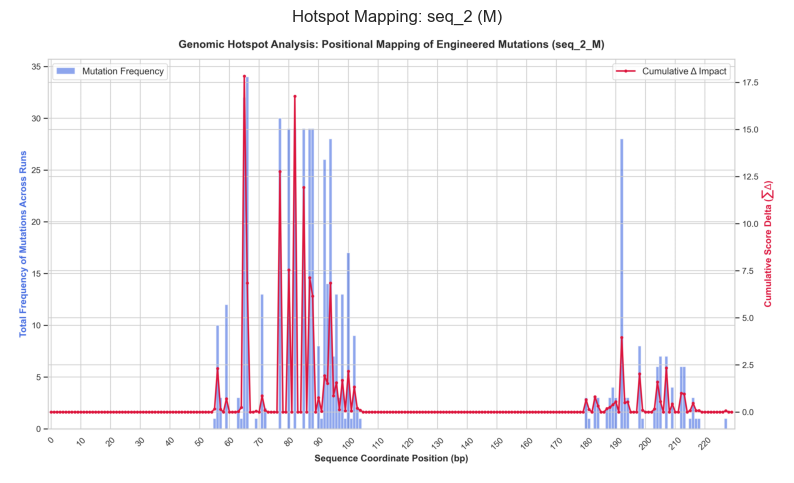

In [ ]:
SEQ_NAME = "seq_2"
OUTPUT_DIRECTORY = "./runs_stochastic/plots/" + SEQ_NAME

for suffix in MODEL_SUFFIXES:
    hotspot_model_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{suffix}_mutation_impact_bars.png")
    if os.path.exists(hotspot_model_path):
        img = Image.open(hotspot_model_path)
        plt.figure(figsize=(10,6))
        plt.axis('off')
        plt.title(f"Hotspot Mapping: {SEQ_NAME} ({suffix})")
        plt.imshow(img)
        plt.show()
    else:
        print(f"Plot file not found: {hotspot_model_path}")

### seq 3

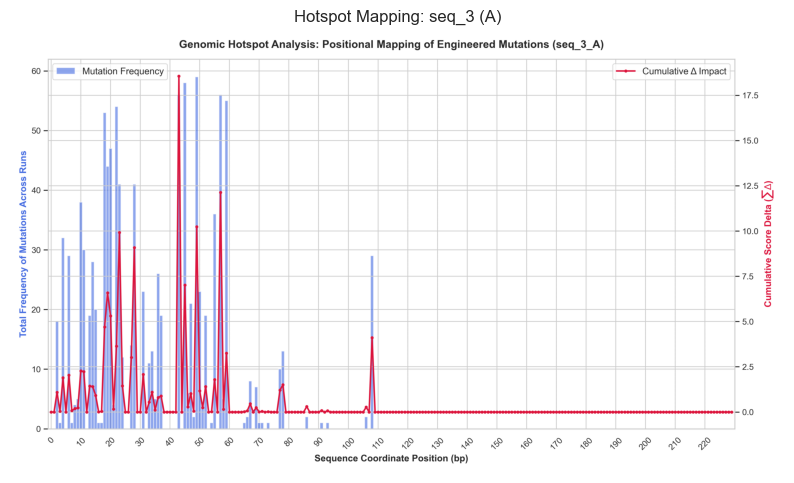

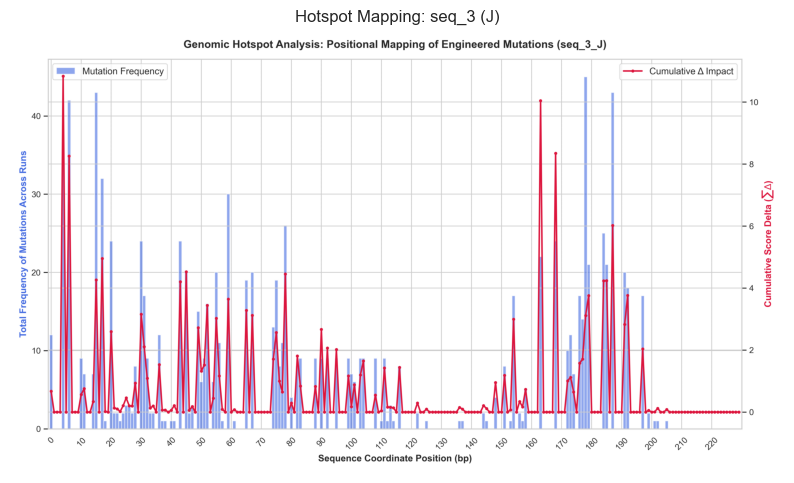

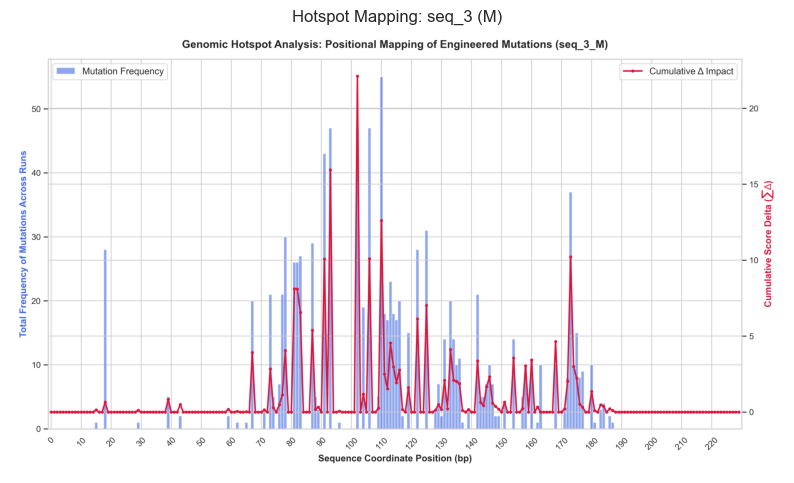

In [ ]:
SEQ_NAME = "seq_3"
OUTPUT_DIRECTORY = "./runs_stochastic/plots/" + SEQ_NAME

for suffix in MODEL_SUFFIXES:
    hotspot_model_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{suffix}_mutation_impact_bars.png")
    if os.path.exists(hotspot_model_path):
        img = Image.open(hotspot_model_path)
        plt.figure(figsize=(10,6))
        plt.axis('off')
        plt.title(f"Hotspot Mapping: {SEQ_NAME} ({suffix})")
        plt.imshow(img)
        plt.show()
    else:
        print(f"Plot file not found: {hotspot_model_path}")

### seq 4

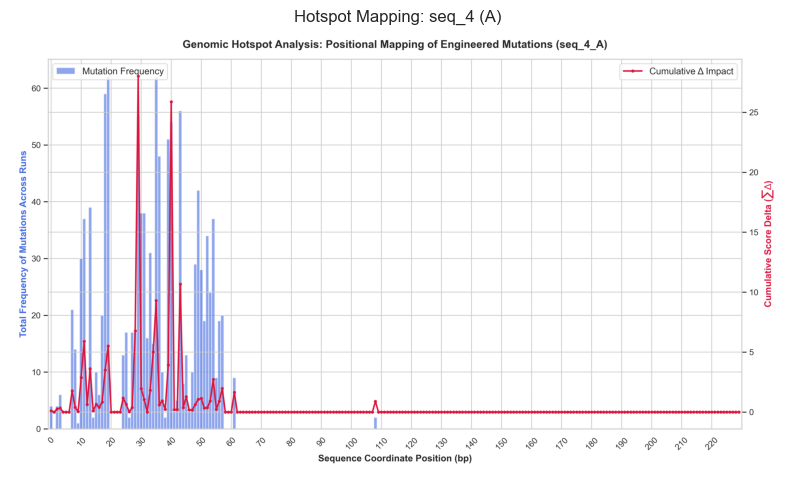

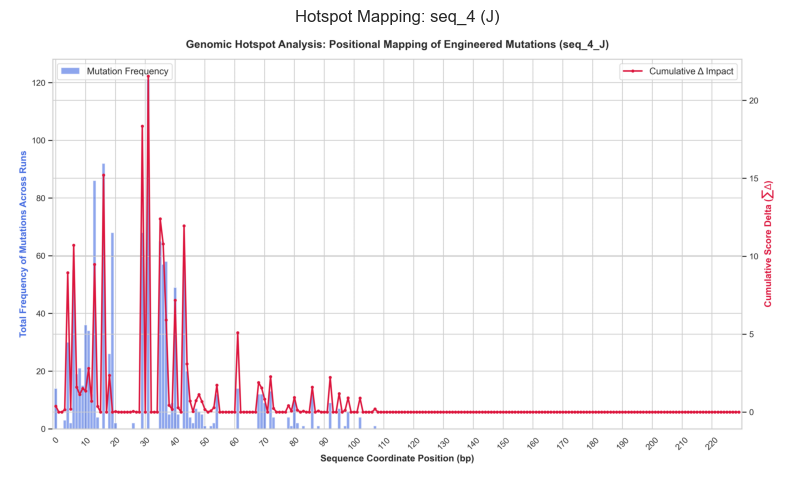

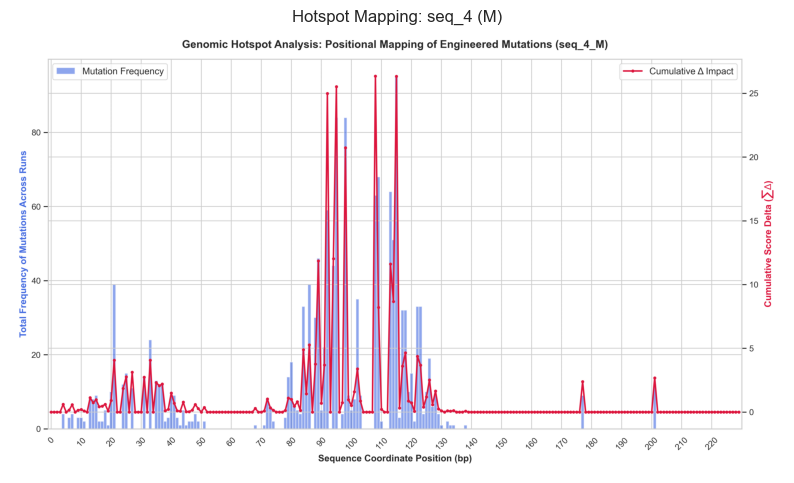

In [ ]:
SEQ_NAME = "seq_4"
OUTPUT_DIRECTORY = "./runs_stochastic/plots/" + SEQ_NAME

for suffix in MODEL_SUFFIXES:
    hotspot_model_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{suffix}_mutation_impact_bars.png")
    if os.path.exists(hotspot_model_path):
        img = Image.open(hotspot_model_path)
        plt.figure(figsize=(10,6))
        plt.axis('off')
        plt.title(f"Hotspot Mapping: {SEQ_NAME} ({suffix})")
        plt.imshow(img)
        plt.show()
    else:
        print(f"Plot file not found: {hotspot_model_path}")

## plots: mutation distribution per position and find the shared mutations between models

idea: check the distribution of specific mutations at a position and find similarities between models

### code

In [ ]:
import os
import re
import glob
import csv
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np

DIRECTORY = "runs_stochastic"
OUTPUT_DIRECTORY = os.path.join(DIRECTORY, "combined")
os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)

In [ ]:
def extract_info_from_filename(filename):
    m = re.search(r'iter(\d+)_win(\d+)', filename)
    return (int(m.group(1)), int(m.group(2))) if m else (None, None)

def parse_mutation(mutation_str):
    m = re.match(r'([ACGT])(\d+)([ACGT])', mutation_str)
    return (int(m.group(2))+1, m.group(1), m.group(3)) if m else (None, None, None)

def load_fasta_positions(fasta_filename):
    seq = ""
    with open(fasta_filename) as f:
        for line in f:
            if not line.startswith(">"):
                seq += line.strip().upper()
    return {i+1: nt for i, nt in enumerate(seq)}

def all_seq_folders():
    return [
        f for f in os.listdir(DIRECTORY)
        if os.path.isdir(os.path.join(DIRECTORY, f)) and f.startswith("seq_")
    ]

def collect_mutation_counts(tsv_files):
    counts = defaultdict(Counter)
    for tsv_file in tsv_files:
        with open(tsv_file) as f:
            next(f) # skip header
            for line in f:
                cols = line.strip().split('\t')
                if len(cols) < 4:
                    continue
                pos, ref, alt = parse_mutation(cols[3])
                if pos:
                    counts[pos][(ref, alt)] += 1
    return counts

def write_csv_per_end(out_dir, pos2nt, counts, all_changes, label, seq_no):
    fields = ["position", "original_nt"] + [f"{f}_to_{t}" for f, t in all_changes]
    fname = os.path.join(out_dir, f"seq_{seq_no}_count_by_position_{label}.csv")
    with open(fname, "w", newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for pos in sorted(counts):
            row = {"position": pos, "original_nt": pos2nt.get(pos,"")}
            for fto in all_changes:
                row[f"{fto[0]}_to_{fto[1]}"] = counts[pos][fto]
            writer.writerow(row)

def read_csv_mut_counts(fname):
    counts = {}
    with open(fname) as f:
        for row in csv.DictReader(f):
            pos = int(row["position"])
            data = {k: int(v) for k,v in row.items() if k not in ("position","original_nt")}
            counts[pos] = data
    return counts


In [ ]:
def analyze_seq(seq_no):
    fasta = f"seq{seq_no}.fa"
    seq_folder = f"seq_{seq_no}"
    input_folder = os.path.join(DIRECTORY, seq_folder)
    if not os.path.exists(fasta) or not os.path.isdir(input_folder):
        print(f"Missing {fasta} or {input_folder}")
        return

    ends = ['_A','_J','_M']
    label_map = {"_A":"A","_J":"J","_M":"M"}
    out_dir = os.path.join(OUTPUT_DIRECTORY, f"seq_{seq_no}")
    os.makedirs(out_dir, exist_ok=True)

    all_changes = set()
    all_counts = {}

    for end in ends:
        tsvs = glob.glob(os.path.join(input_folder, f"seq_{seq_no}_*{end}.tsv"))
        counts = collect_mutation_counts(tsvs)
        all_counts[end] = counts
        for v in counts.values():
            all_changes |= set(v.keys())
    all_changes = sorted(all_changes)

    pos2nt = load_fasta_positions(fasta)

    for end in ends:
        write_csv_per_end(out_dir, pos2nt, all_counts[end], all_changes, label_map[end], seq_no)

    #shared mutations between models
    labels = [label_map[e] for e in ends]
    csv_files = [os.path.join(out_dir, f"seq_{seq_no}_count_by_position_{l}.csv") for l in labels]
    mut_per_file = [read_csv_mut_counts(f) for f in csv_files]

    all_positions = sorted(set(pos for d in mut_per_file for pos in d))
    shared_per_pos = {}

    for pos in all_positions:
        muts_per_file = [{m for m,v in d.get(pos,{}).items() if v>0} for d in mut_per_file]
        common = set.intersection(*muts_per_file) if muts_per_file else set()
        if common:
            shared_per_pos[pos] = common

    # Save shared mutations per position to a CSV
    shared_csv_path = os.path.join(out_dir, f"seq_{seq_no}_shared_mutations.csv")
    with open(shared_csv_path, 'w', newline='') as csvfile:
        fieldnames = ['position', 'mutation'] + labels
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for pos in sorted(shared_per_pos):
            for mut in sorted(shared_per_pos[pos]):
                counts = [mut_per_file[i].get(pos,{}).get(mut,0) for i in range(3)]
                row = {
                    'position': pos,
                    'mutation': mut,
                    labels[0]: counts[0],
                    labels[1]: counts[1],
                    labels[2]: counts[2]
                }
                writer.writerow(row)
                print(row)

    # print(f"Shared mutations saved to {shared_csv_path}")


    # Plot heatmap and stacked bar for each ending
    plot_min, plot_max = 0, 230
    n_pos = plot_max - plot_min + 1
    positions = np.arange(plot_min, plot_max+1)
    mutation_types = [f"{f}_to_{t}" for f,t in all_changes]
    for file, label in zip(csv_files, labels):
        if not os.path.isfile(file):
            continue
        arr = np.zeros((n_pos, len(mutation_types)), dtype=int)
        with open(file) as f:
            for row in csv.DictReader(f):
                pos = int(row["position"])
                idx = pos - plot_min
                if idx<0 or idx>=n_pos: continue
                for j, mut in enumerate(mutation_types):
                    arr[idx,j] = int(row.get(mut,0))

        # Heatmap
        plt.figure(figsize=(max(10,len(mutation_types)*0.7),8))
        im = plt.imshow(arr, aspect='auto', cmap='plasma', origin='upper')
        plt.colorbar(im, label='Count')
        plt.yticks(np.linspace(0,n_pos-1,10), np.linspace(plot_min,plot_max,10, dtype=int))
        plt.xticks(range(len(mutation_types)), mutation_types, rotation=45, ha='right')
        plt.xlabel('Mutation (from_to)')
        plt.ylabel('Position')
        plt.title(f"Mutation Counts by Position seq_{seq_no} ({label})")
        plt.tight_layout()
        png = os.path.join(out_dir, f"seq_{seq_no}_count_by_position_{label}.png")
        plt.savefig(png, dpi=200)
        # print(f"Plot saved to {png}")
        # Optionally save also to input folder if exists
        input_png = os.path.join(input_folder, f"seq_{seq_no}_count_by_position_{label}.png")
        if os.path.isdir(input_folder):
            plt.savefig(input_png, dpi=200)
        plt.close()

        # Stacked bar plot
        plt.figure(figsize=(max(10,n_pos*0.05),7))
        bottom = np.zeros(n_pos)
        for j, mut in enumerate(mutation_types):
            plt.bar(positions, arr[:,j], bottom=bottom, label=mut, width=1.0)
            bottom += arr[:,j]
        plt.xlim(plot_min, plot_max)
        plt.xlabel("Position")
        plt.ylabel("Count")
        plt.title(f"Stacked Mutation Counts by Position seq_{seq_no} ({label})")
        plt.legend(title="Mutation", bbox_to_anchor=(1.01,1), loc='upper left', fontsize='small')
        plt.tight_layout()
        barpng = os.path.join(out_dir, f"seq_{seq_no}_mutation_stack_by_position_{label}.png")
        plt.savefig(barpng, dpi=200)
        # print(f"Stacked bar plot saved to {barpng}")
        input_bar_png = os.path.join(input_folder, f"seq_{seq_no}_mutation_stack_by_position_{label}.png")
        if os.path.isdir(input_folder):
            plt.savefig(input_bar_png, dpi=200)
        plt.close()


In [ ]:
if not os.path.exists(DIRECTORY):
    print(f"Base data directory '{DIRECTORY}' not found.")
else:
    folders = all_seq_folders()
    if not folders:
        print("No sequence folders found in data directory.")
    else:
        for folder in folders:
            seq_no = folder.split("_")[-1]
            print(f"----- Analyzing sequence {seq_no} ({folder}) -----")
            analyze_seq(seq_no)

----- Analyzing sequence 1 (seq_1) -----
{'position': 59, 'mutation': 'A_to_G', 'A': 5, 'J': 3, 'M': 1}
{'position': 81, 'mutation': 'T_to_A', 'A': 5, 'J': 1, 'M': 1}
{'position': 85, 'mutation': 'A_to_C', 'A': 2, 'J': 15, 'M': 1}
{'position': 90, 'mutation': 'G_to_A', 'A': 2, 'J': 3, 'M': 1}
{'position': 95, 'mutation': 'T_to_C', 'A': 16, 'J': 16, 'M': 1}
{'position': 97, 'mutation': 'A_to_T', 'A': 15, 'J': 20, 'M': 8}
{'position': 106, 'mutation': 'G_to_A', 'A': 1, 'J': 5, 'M': 2}
{'position': 107, 'mutation': 'T_to_G', 'A': 10, 'J': 6, 'M': 5}
{'position': 108, 'mutation': 'C_to_T', 'A': 2, 'J': 6, 'M': 1}
{'position': 110, 'mutation': 'A_to_G', 'A': 7, 'J': 5, 'M': 6}
{'position': 120, 'mutation': 'T_to_C', 'A': 1, 'J': 5, 'M': 5}
----- Analyzing sequence 2 (seq_2) -----
{'position': 60, 'mutation': 'C_to_G', 'A': 2, 'J': 1, 'M': 12}
{'position': 95, 'mutation': 'A_to_G', 'A': 4, 'J': 2, 'M': 28}
----- Analyzing sequence 3 (seq_3) -----
{'position': 19, 'mutation': 'C_to_G', 'A': 1

### seq 1

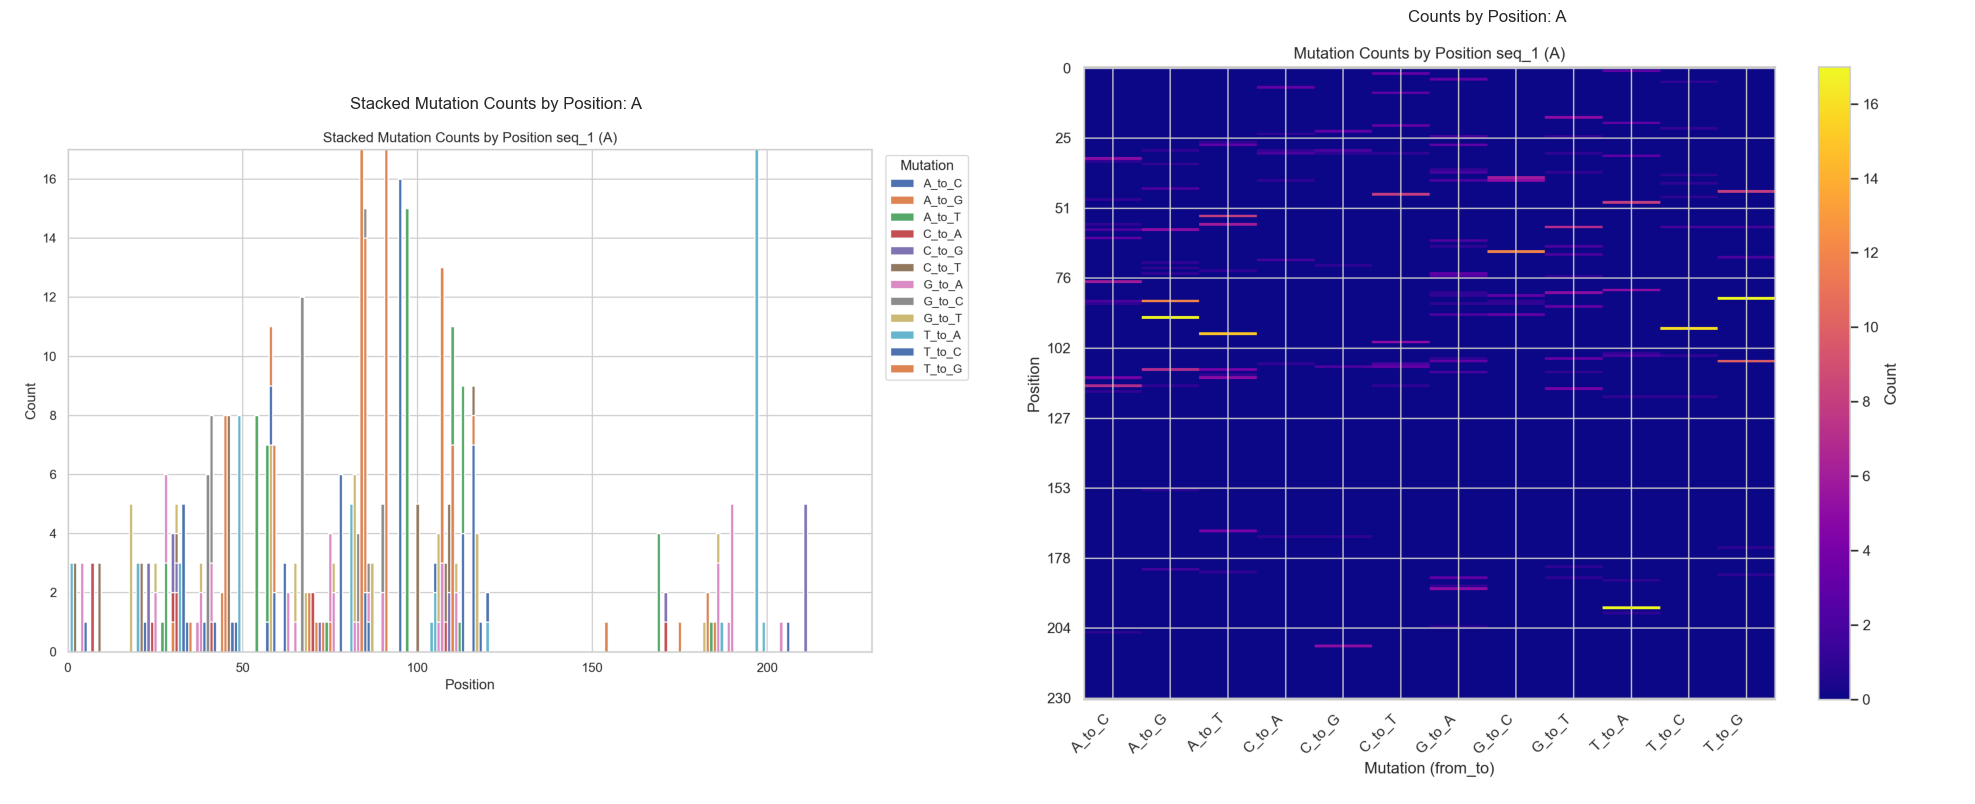

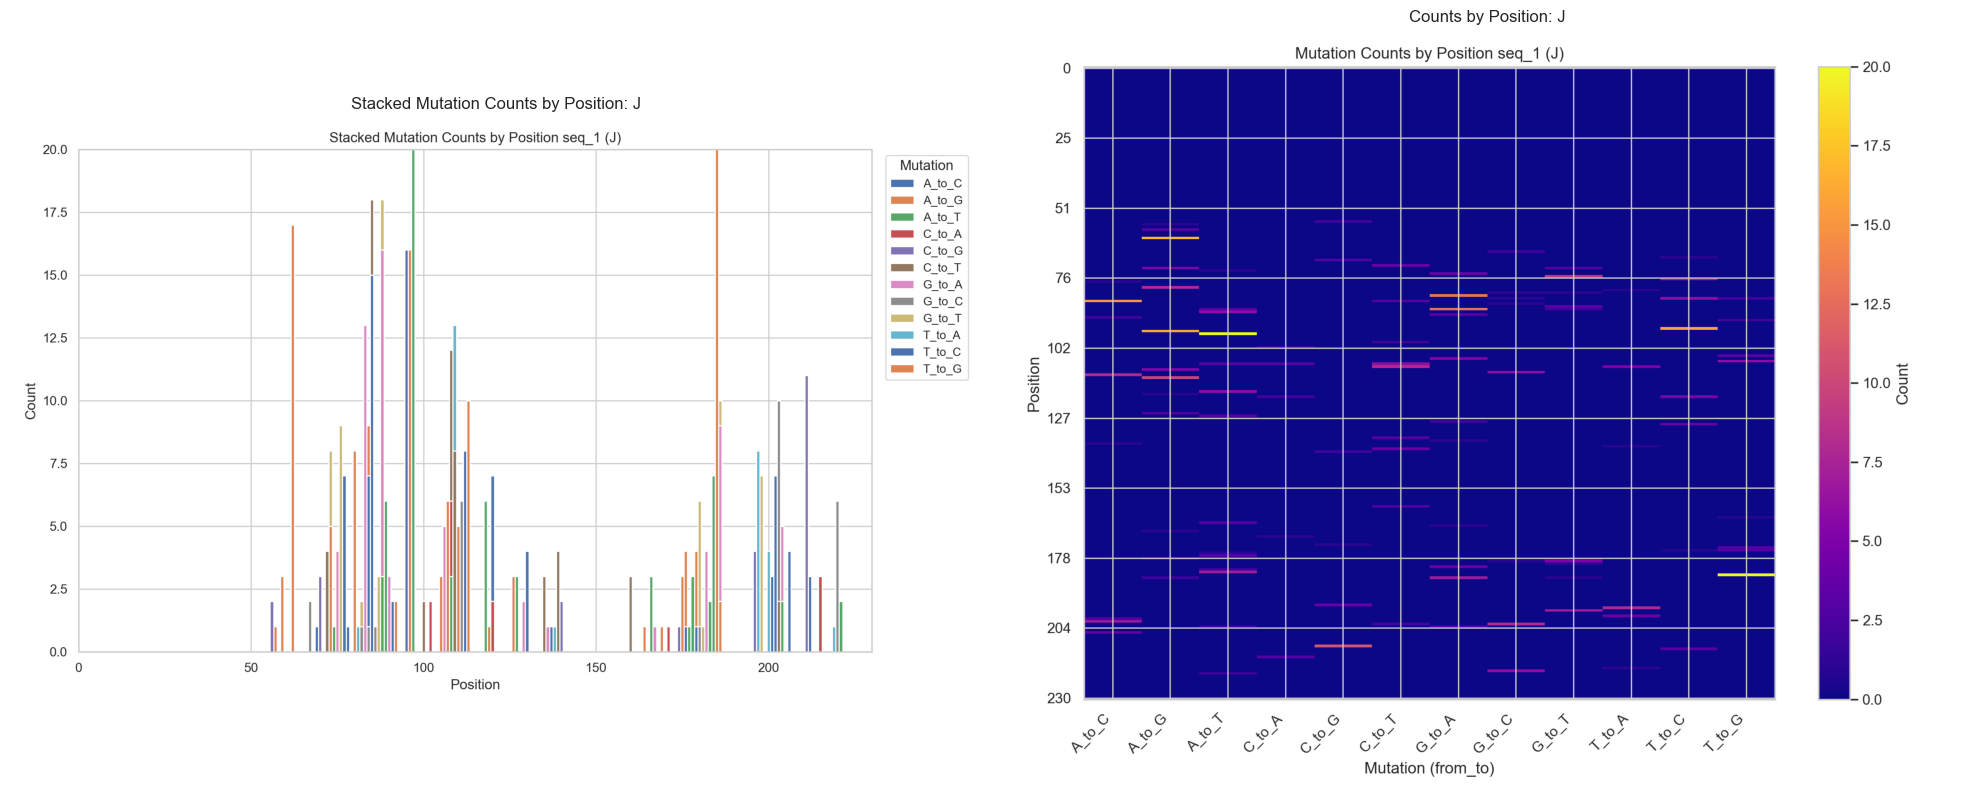

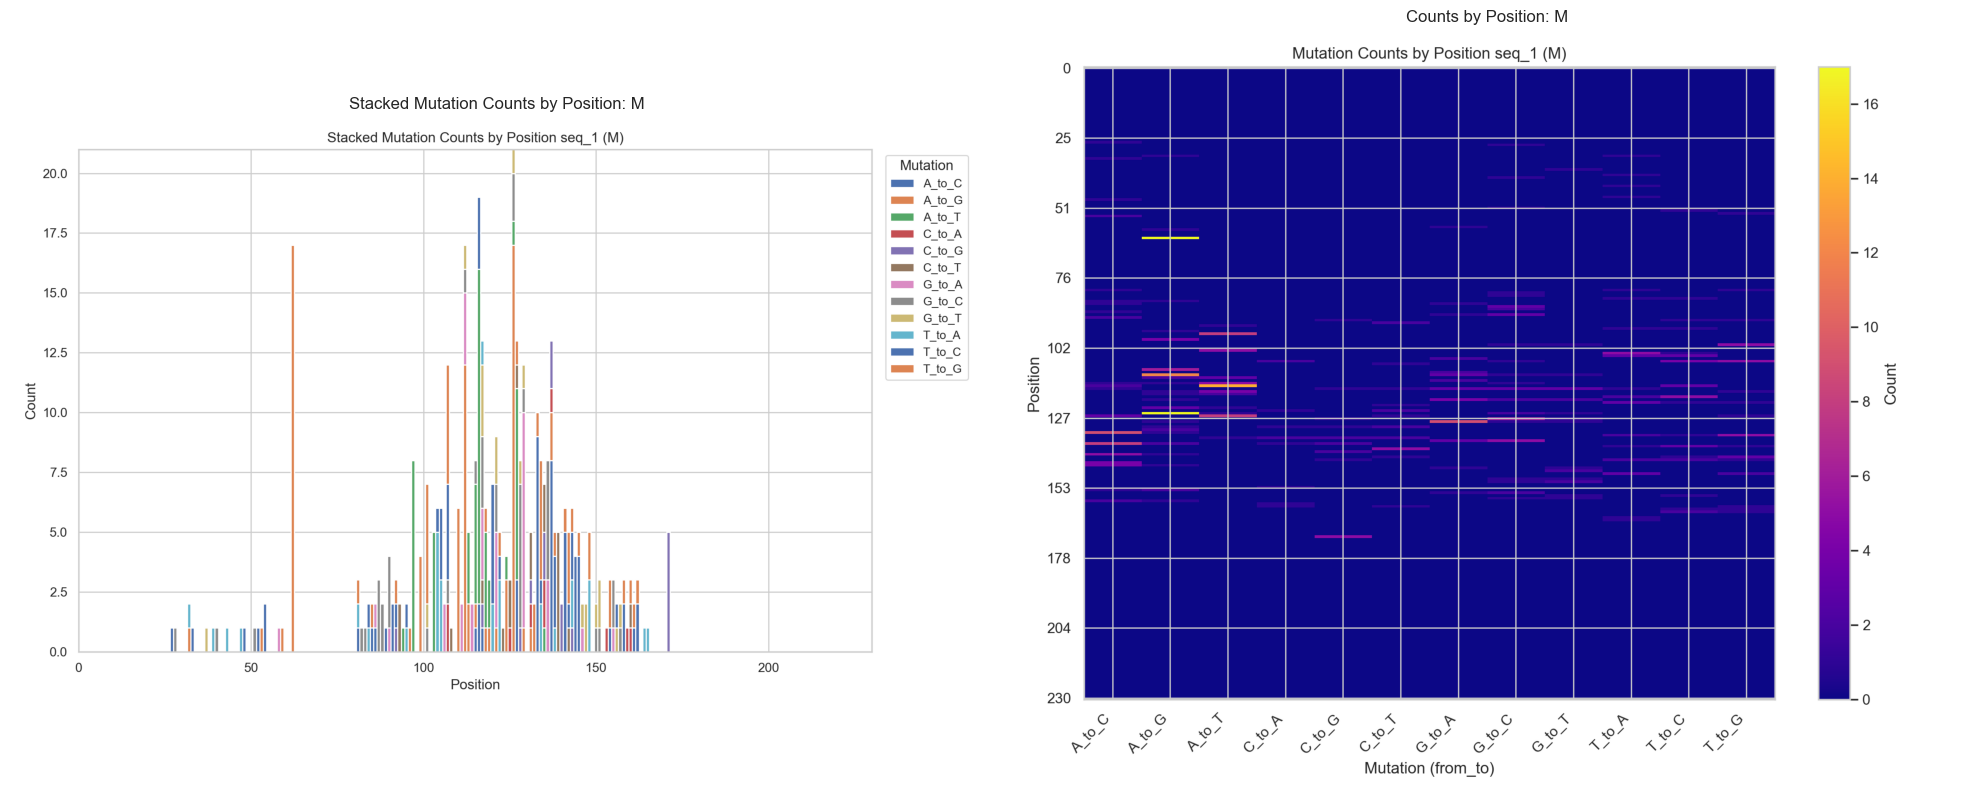

In [ ]:
SEQ_NAME = "seq_1"
OUTPUT_DIRECTORY = "./runs_stochastic/combined/" + SEQ_NAME

from PIL import Image

suffixes = ["A", "J", "M"]
png_types = ["count_by_position", "mutation_stack_by_position"]

figsize = (20, 8)

for suffix in suffixes:
    image_paths = []
    titles = []
    for png_type in png_types:
        img_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{png_type}_{suffix}.png")
        image_paths.append(img_path)
        if png_type == "count_by_position":
            titles.append(f"Counts by Position: {suffix}")
        else:
            titles.append(f"Stacked Mutation Counts by Position: {suffix}")

    images = []
    for img_path in image_paths:
        if os.path.exists(img_path):
            images.append(Image.open(img_path))
        else:
            images.append(None)
            print(f"Plot file not found: {img_path}")

    if any(img is not None for img in images):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        for i, (img, title) in enumerate(zip(reversed(images), reversed(titles))):
            axes[i].axis('off')
            axes[i].set_title(title)
            if img is not None:
                axes[i].imshow(img)
            else:
                axes[i].text(0.5, 0.5, "File not found", ha='center', va='center', fontsize=16)
        plt.tight_layout()
        plt.show()

### seq 2

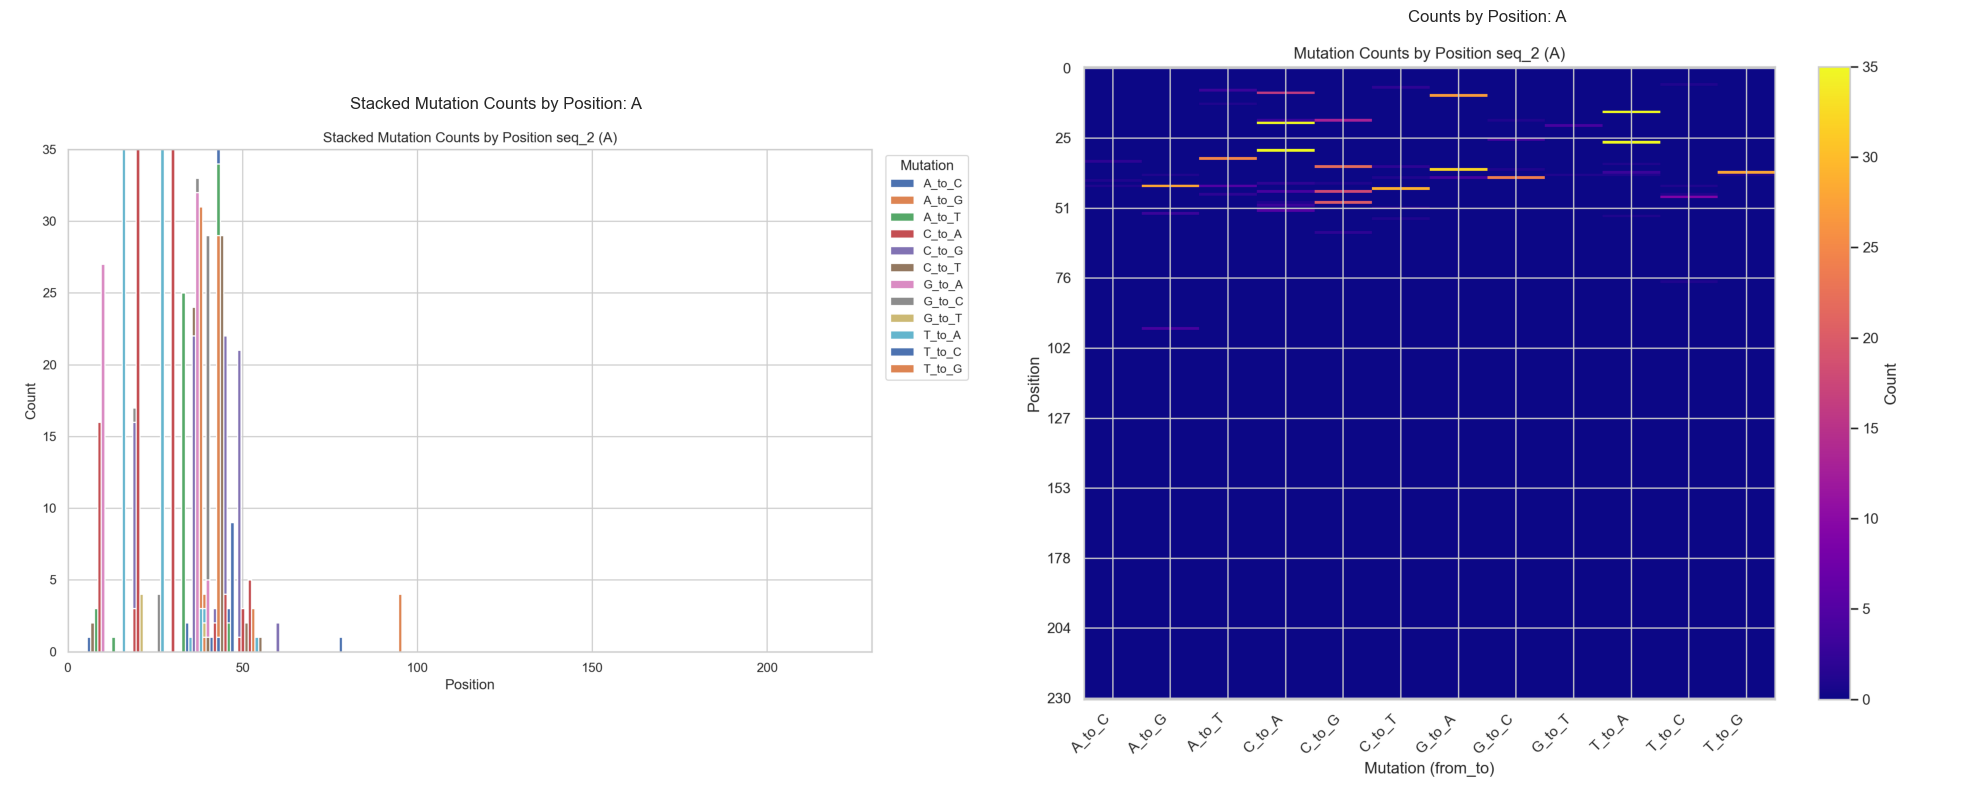

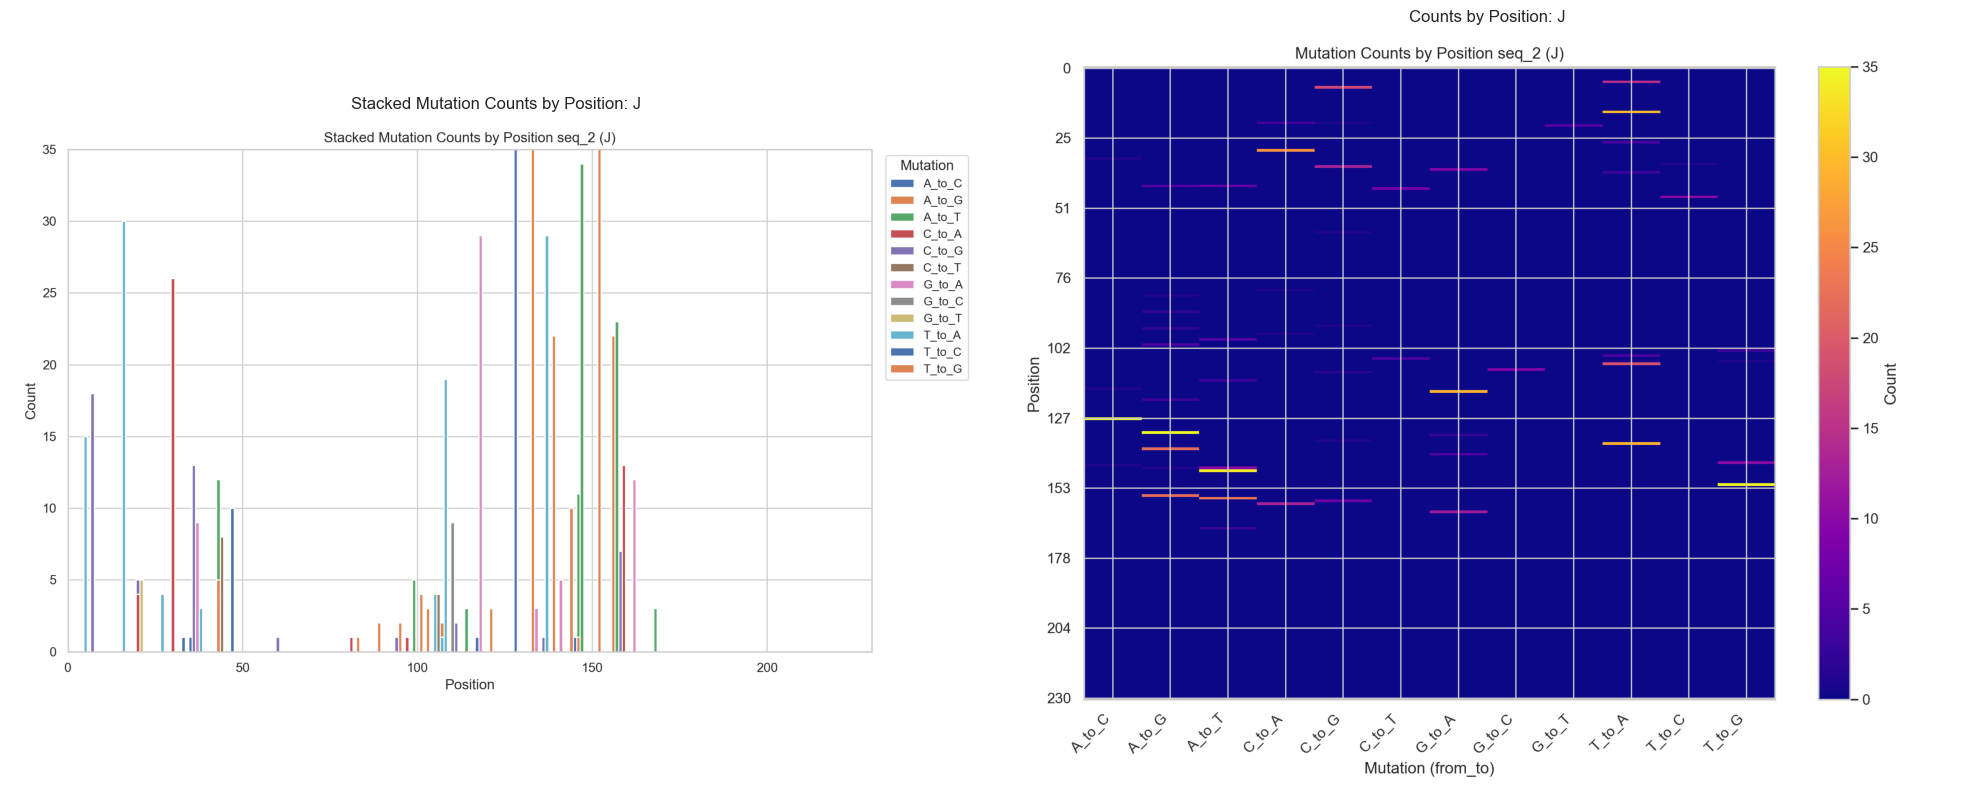

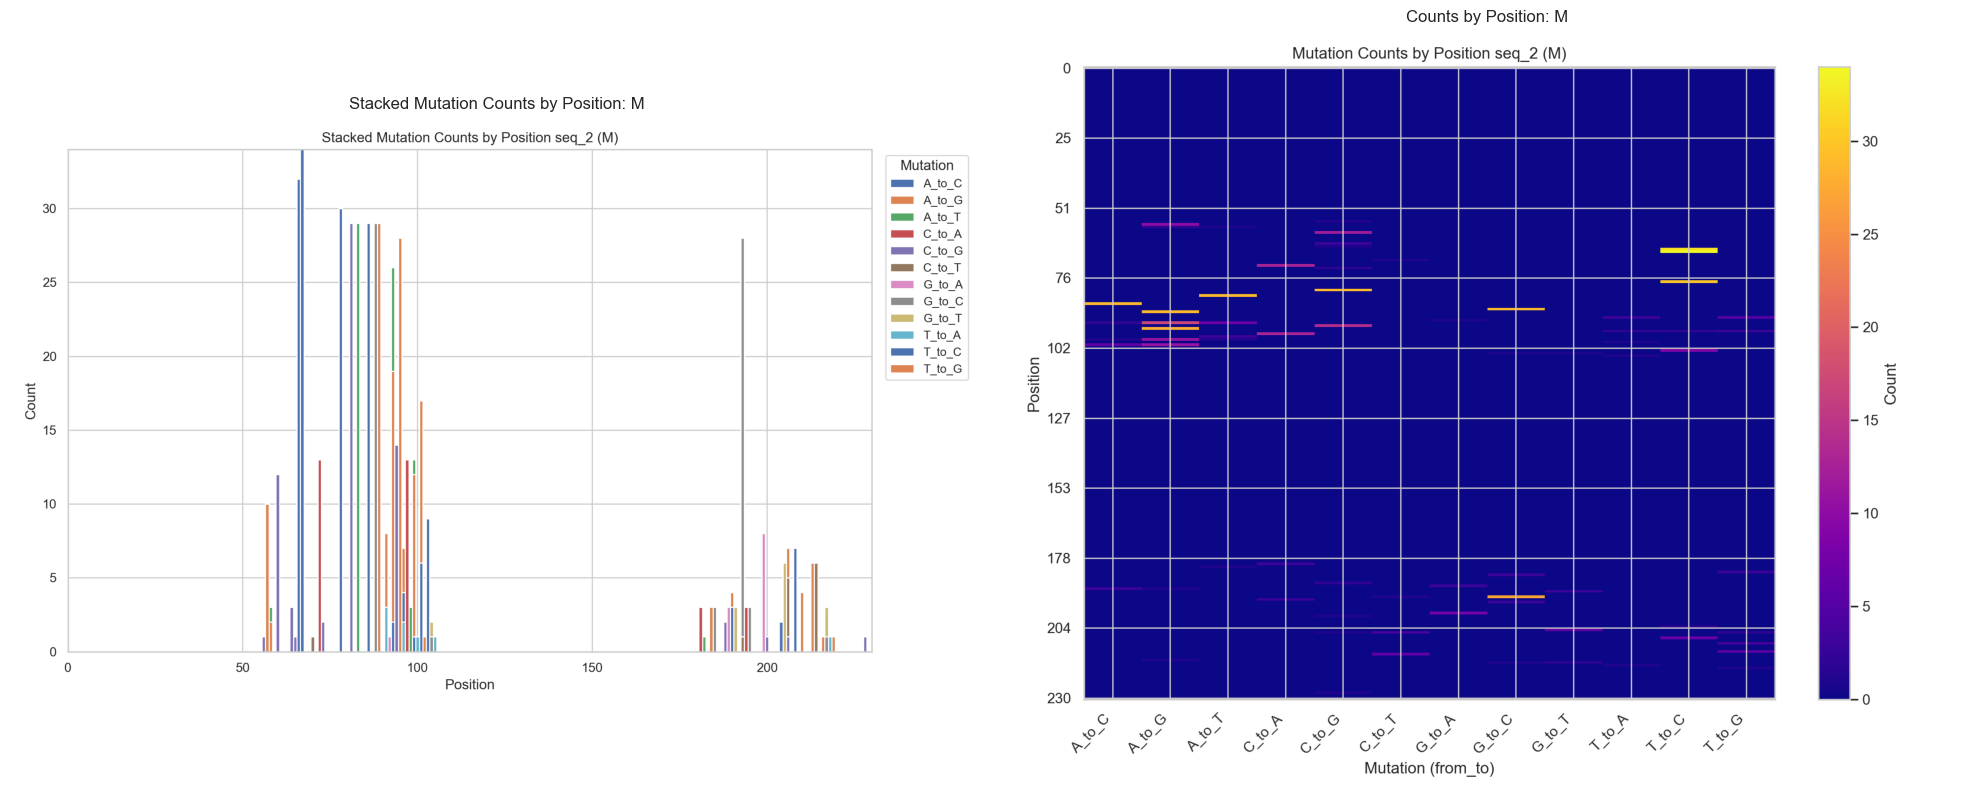

In [ ]:
SEQ_NAME = "seq_2"
OUTPUT_DIRECTORY = "./runs_stochastic/combined/" + SEQ_NAME

from PIL import Image

suffixes = ["A", "J", "M"]
png_types = ["count_by_position", "mutation_stack_by_position"]

figsize = (20, 8)

for suffix in suffixes:
    image_paths = []
    titles = []
    for png_type in png_types:
        img_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{png_type}_{suffix}.png")
        image_paths.append(img_path)
        if png_type == "count_by_position":
            titles.append(f"Counts by Position: {suffix}")
        else:
            titles.append(f"Stacked Mutation Counts by Position: {suffix}")

    images = []
    for img_path in image_paths:
        if os.path.exists(img_path):
            images.append(Image.open(img_path))
        else:
            images.append(None)
            print(f"Plot file not found: {img_path}")

    if any(img is not None for img in images):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        for i, (img, title) in enumerate(zip(reversed(images), reversed(titles))):
            axes[i].axis('off')
            axes[i].set_title(title)
            if img is not None:
                axes[i].imshow(img)
            else:
                axes[i].text(0.5, 0.5, "File not found", ha='center', va='center', fontsize=16)
        plt.tight_layout()
        plt.show()

### seq 3

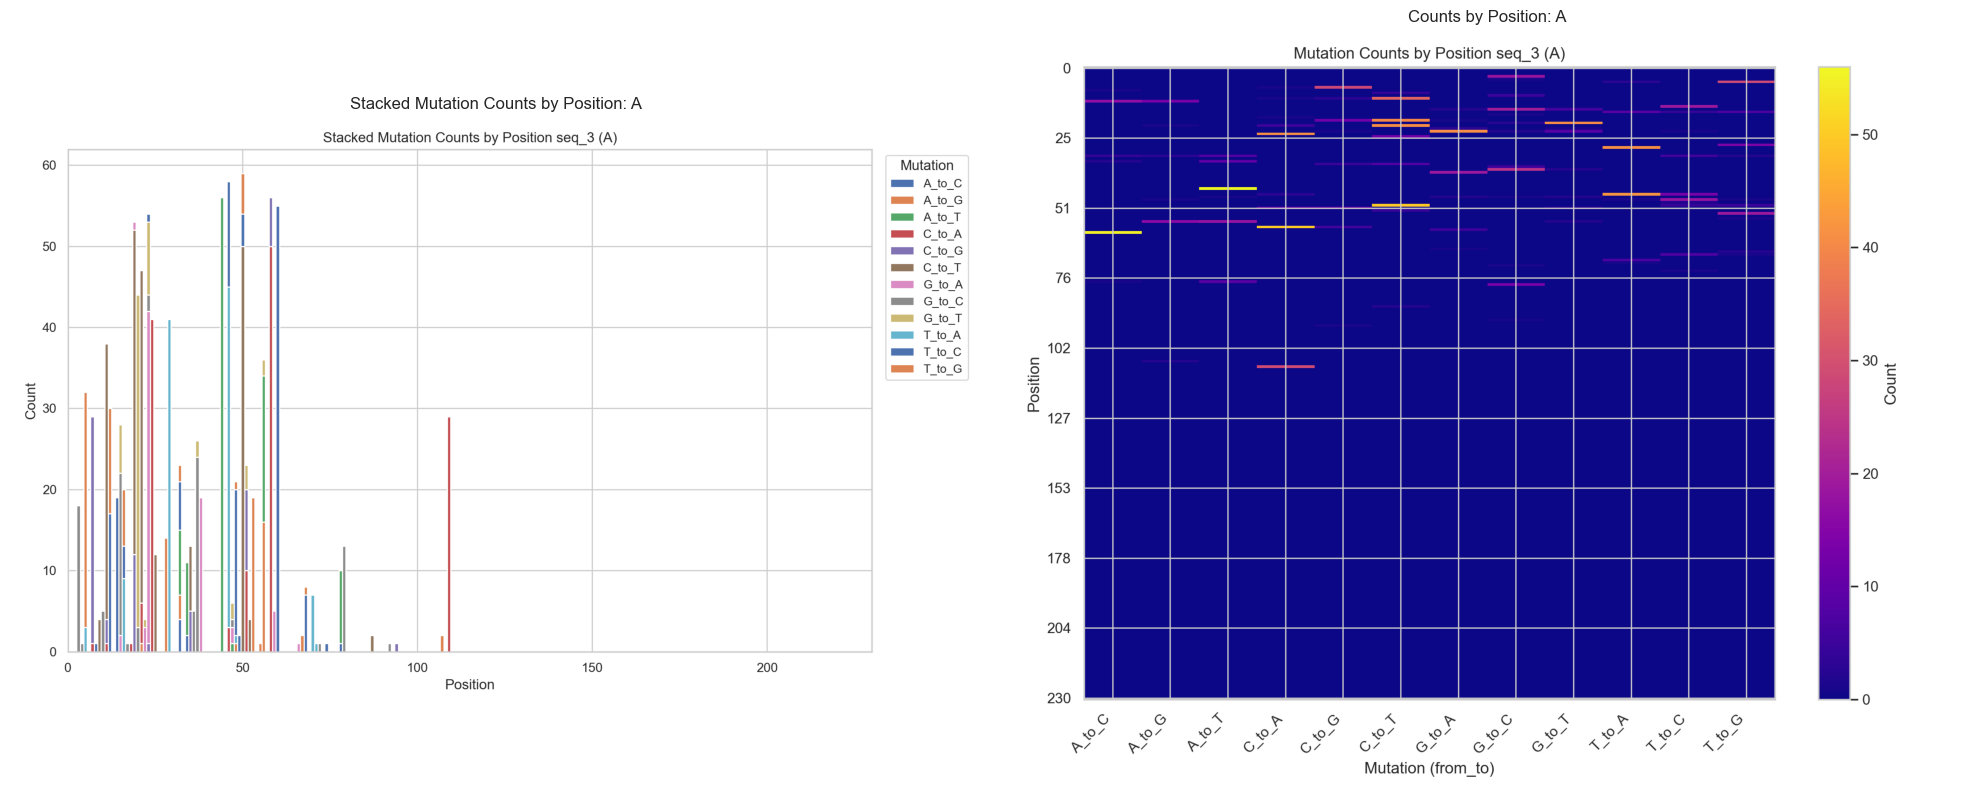

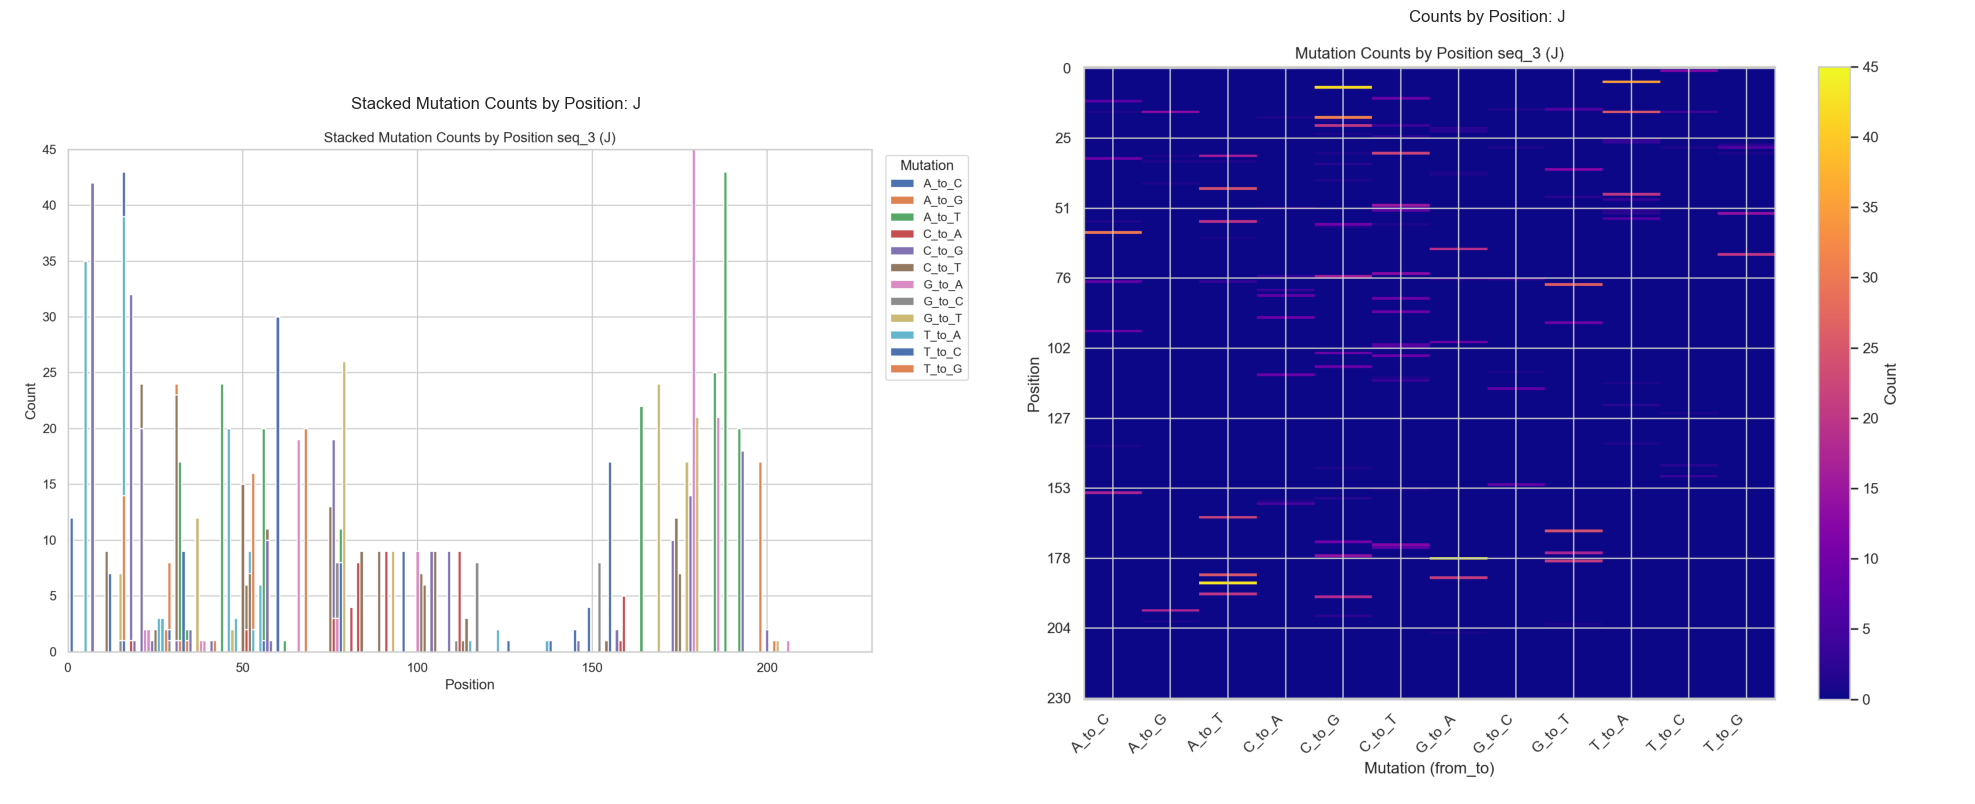

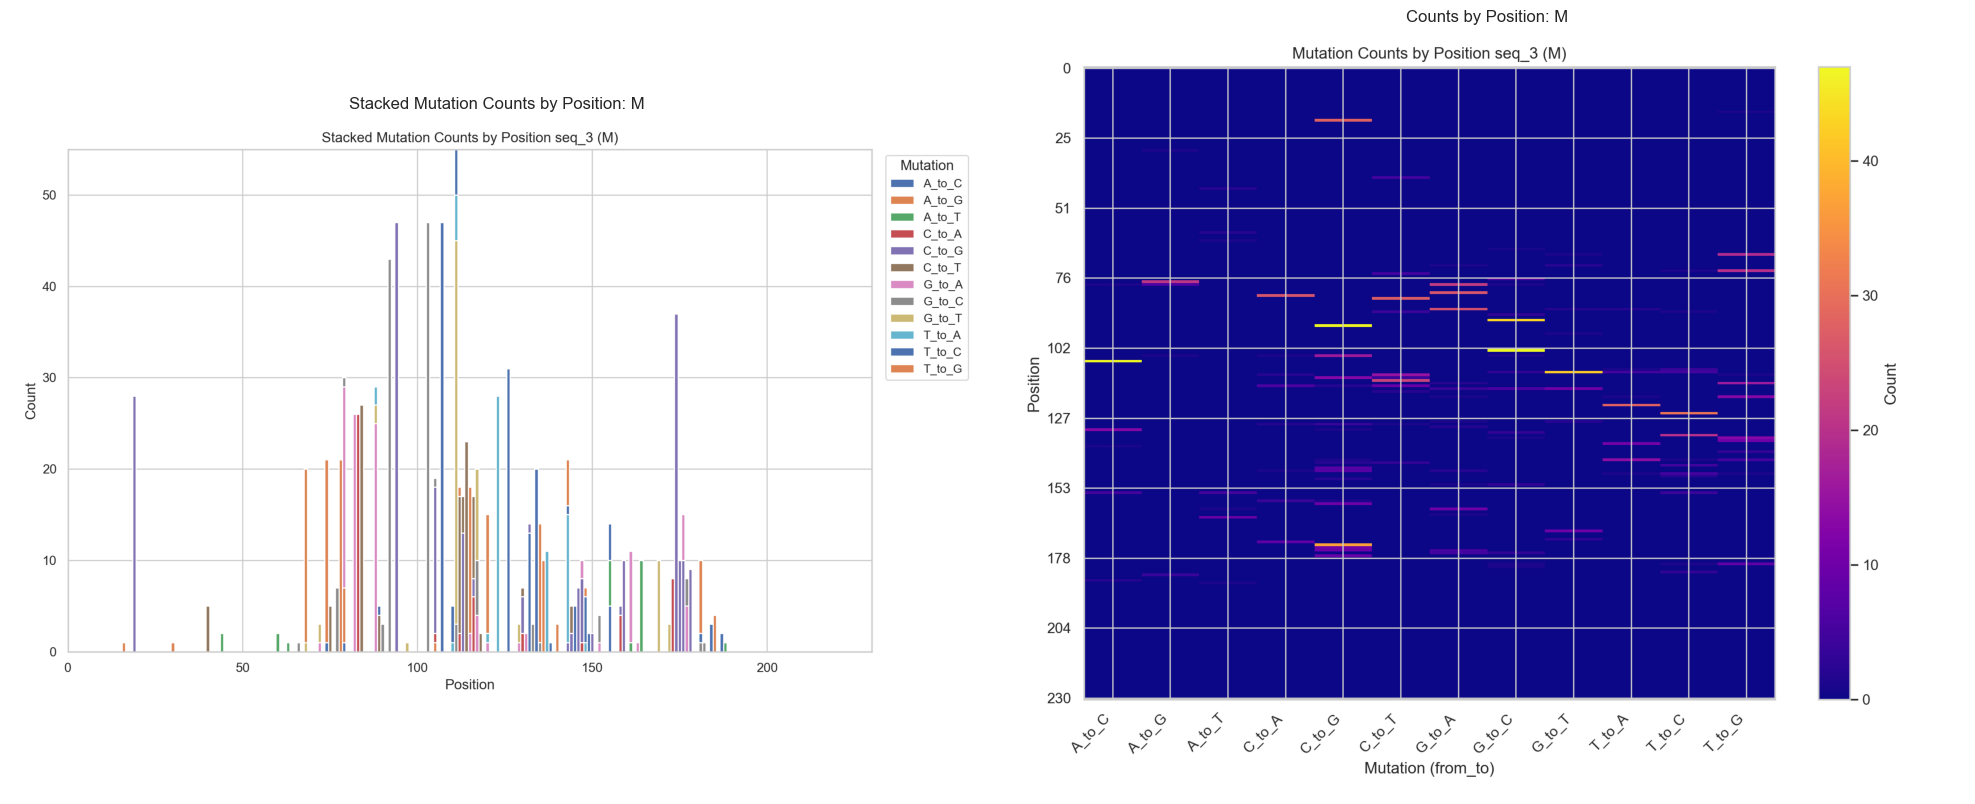

In [ ]:
SEQ_NAME = "seq_3"
OUTPUT_DIRECTORY = "./runs_stochastic/combined/" + SEQ_NAME

from PIL import Image

suffixes = ["A", "J", "M"]
png_types = ["count_by_position", "mutation_stack_by_position"]

figsize = (20, 8)

for suffix in suffixes:
    image_paths = []
    titles = []
    for png_type in png_types:
        img_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{png_type}_{suffix}.png")
        image_paths.append(img_path)
        if png_type == "count_by_position":
            titles.append(f"Counts by Position: {suffix}")
        else:
            titles.append(f"Stacked Mutation Counts by Position: {suffix}")

    images = []
    for img_path in image_paths:
        if os.path.exists(img_path):
            images.append(Image.open(img_path))
        else:
            images.append(None)
            print(f"Plot file not found: {img_path}")

    if any(img is not None for img in images):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        for i, (img, title) in enumerate(zip(reversed(images), reversed(titles))):
            axes[i].axis('off')
            axes[i].set_title(title)
            if img is not None:
                axes[i].imshow(img)
            else:
                axes[i].text(0.5, 0.5, "File not found", ha='center', va='center', fontsize=16)
        plt.tight_layout()
        plt.show()

### seq 4

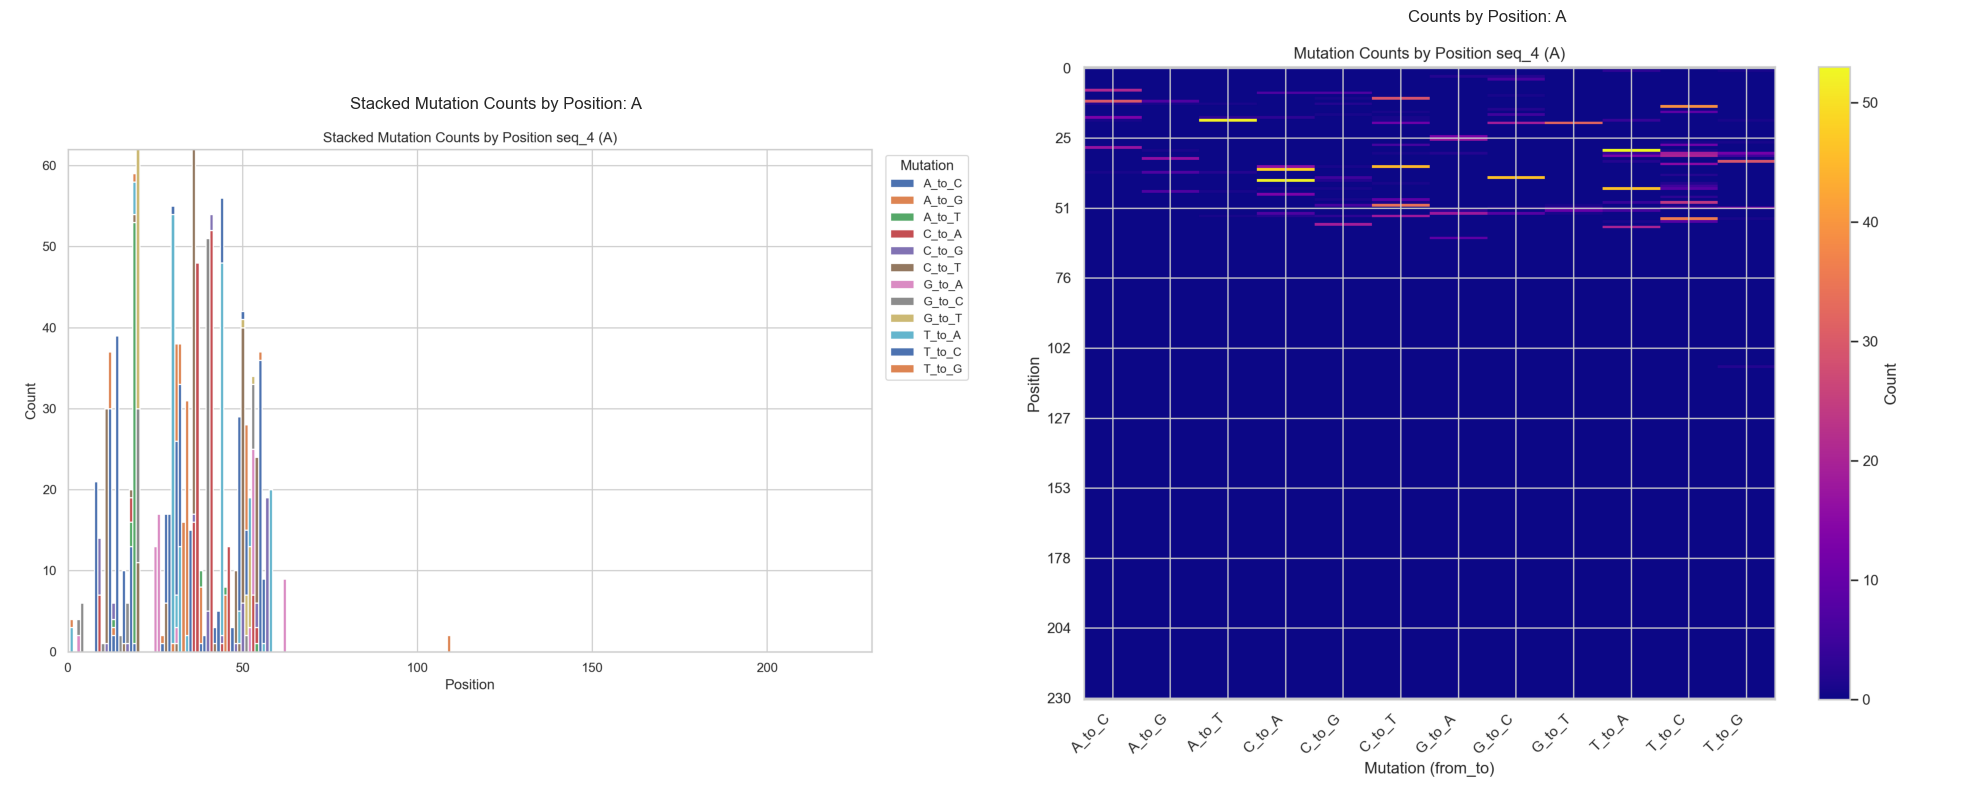

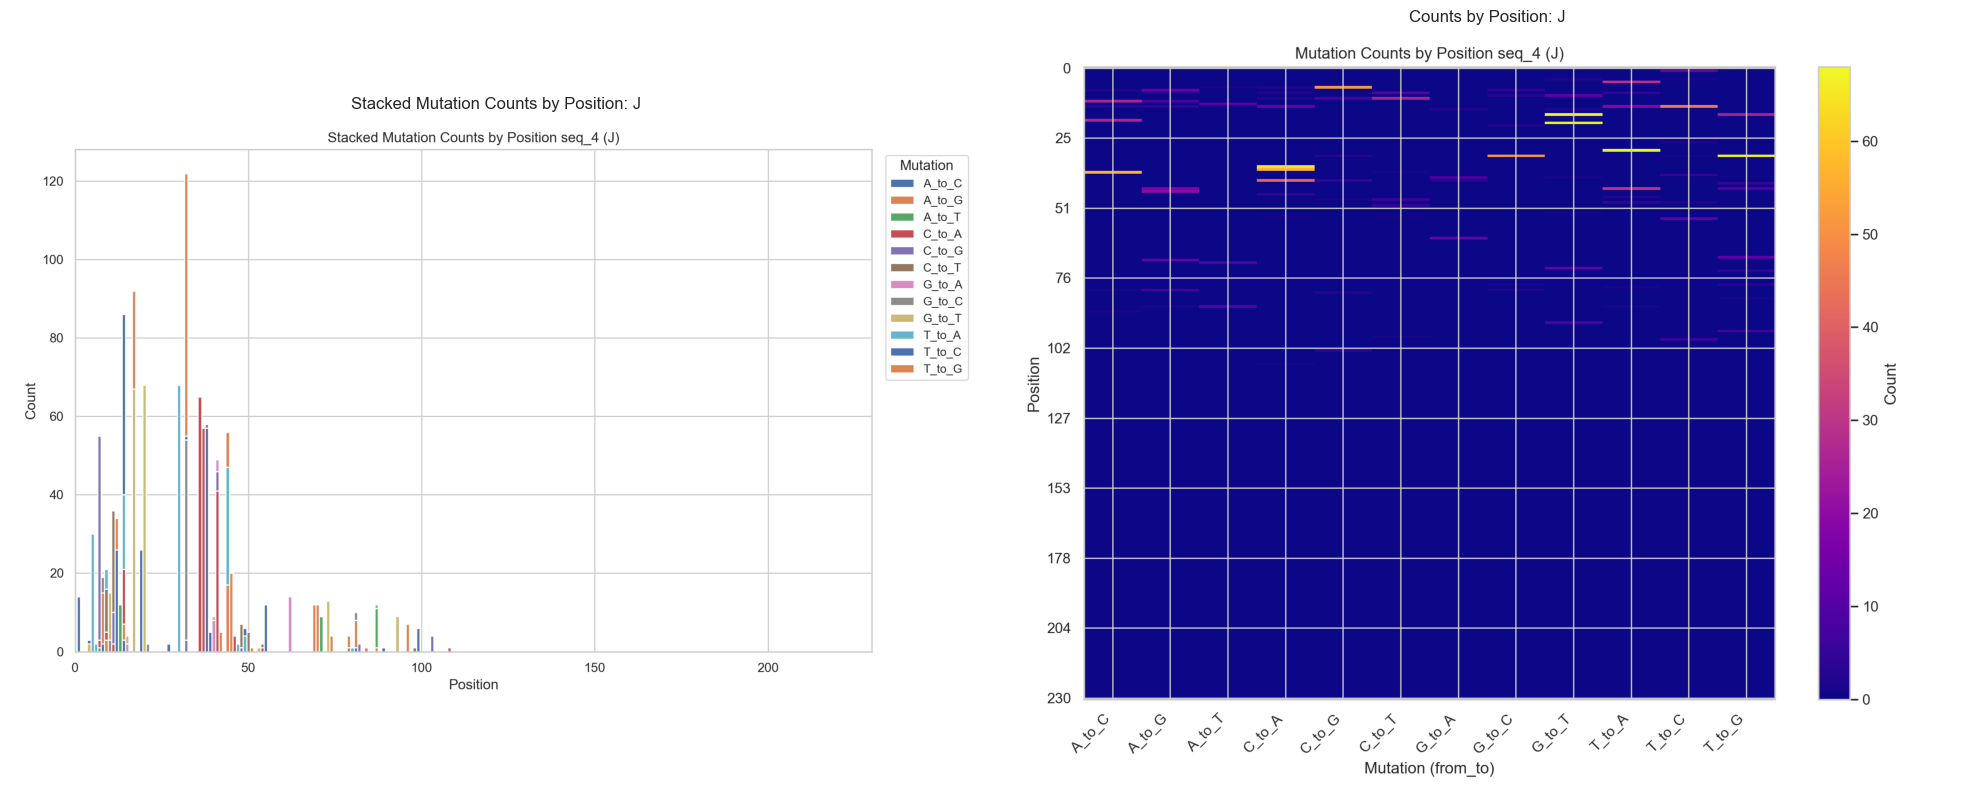

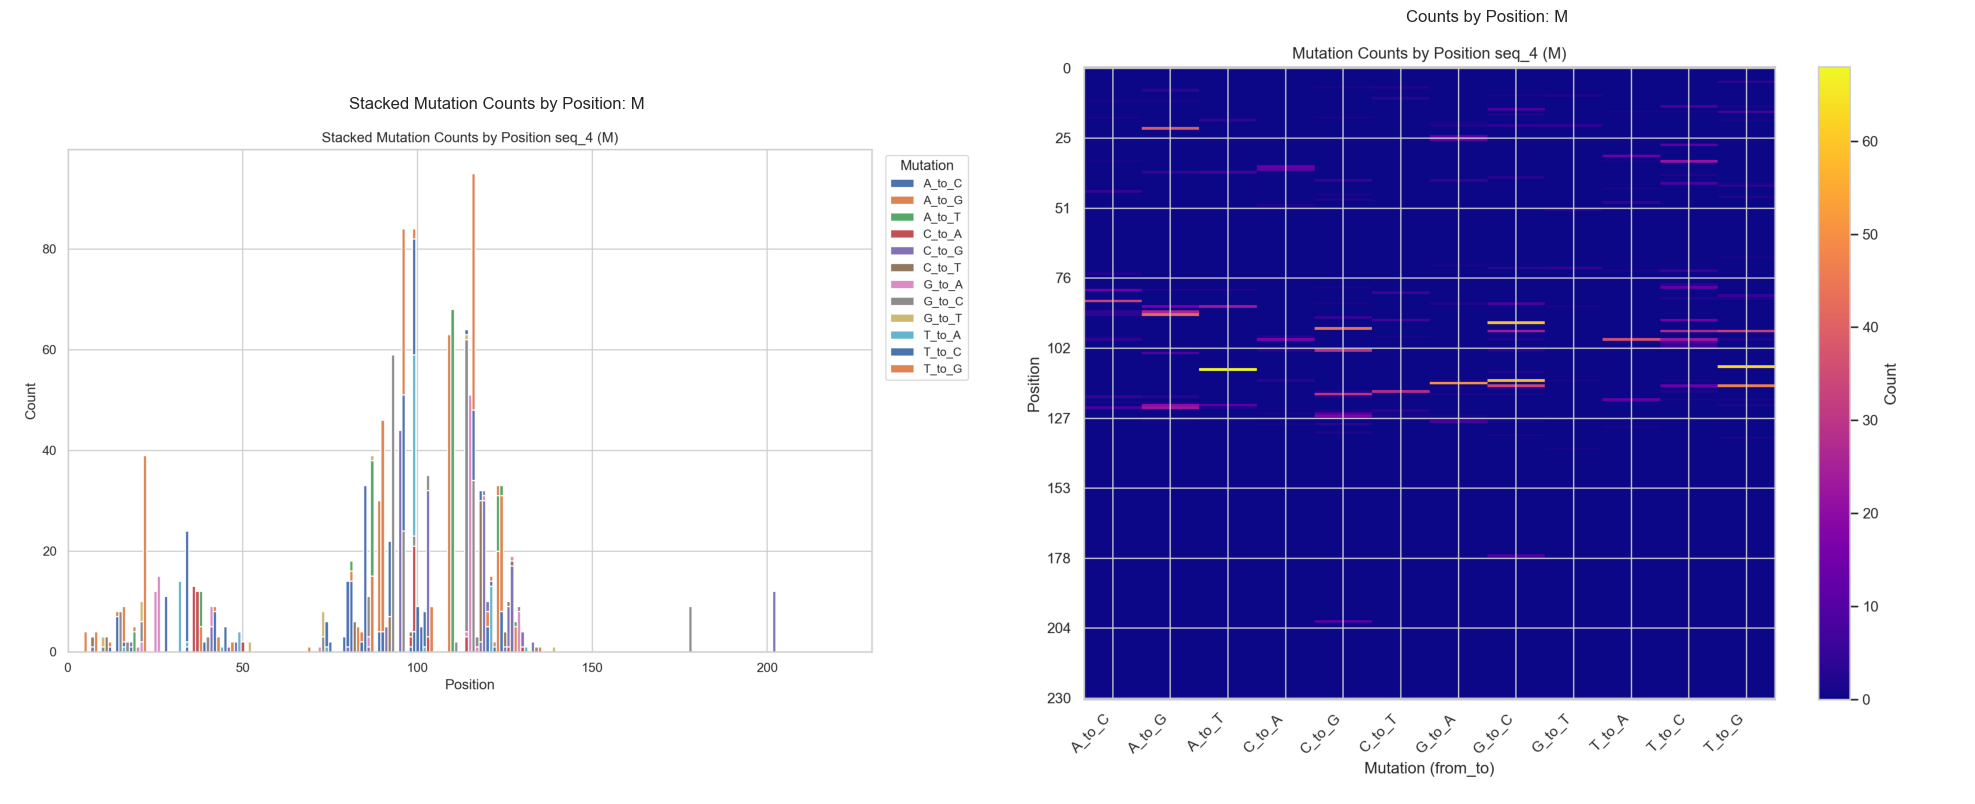

In [ ]:
SEQ_NAME = "seq_4"
OUTPUT_DIRECTORY = "./runs_stochastic/combined/" + SEQ_NAME

from PIL import Image

suffixes = ["A", "J", "M"]
png_types = ["count_by_position", "mutation_stack_by_position"]

figsize = (20, 8)

for suffix in suffixes:
    image_paths = []
    titles = []
    for png_type in png_types:
        img_path = os.path.join(OUTPUT_DIRECTORY, f"{SEQ_NAME}_{png_type}_{suffix}.png")
        image_paths.append(img_path)
        if png_type == "count_by_position":
            titles.append(f"Counts by Position: {suffix}")
        else:
            titles.append(f"Stacked Mutation Counts by Position: {suffix}")

    images = []
    for img_path in image_paths:
        if os.path.exists(img_path):
            images.append(Image.open(img_path))
        else:
            images.append(None)
            print(f"Plot file not found: {img_path}")

    if any(img is not None for img in images):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        for i, (img, title) in enumerate(zip(reversed(images), reversed(titles))):
            axes[i].axis('off')
            axes[i].set_title(title)
            if img is not None:
                axes[i].imshow(img)
            else:
                axes[i].text(0.5, 0.5, "File not found", ha='center', va='center', fontsize=16)
        plt.tight_layout()
        plt.show()

## highest scored runs for each sequence for each model

idea: find the highest scores between the runs; separate for each model (so ultimately one input sequce will have three outputs to choose from)

to determine which of the three to choose from conduct a weighted mean, where the weights mirror the rank the individual models in accuracy (as model M was the lowest, also a weighted mean without it was done).

present those with the highest score

In [ ]:
import os
import re

nruns = 'runs_stochastic'
highest = []

for seq_no in ['seq_1','seq_2','seq_3','seq_4']:
    dirc = os.path.join(nruns, seq_no)

    print(f"_________seq_no: {seq_no}_________")

    highest_per_ending = dict()

    ending_re = re.compile(r'(_[A-Z])\.tsv$')

    for filename in os.listdir(dirc):
        if filename.startswith(seq_no) and filename.endswith('.tsv'):
            ending_match = ending_re.search(filename)
            if not ending_match:
                continue
            ending = ending_match.group(1)
            file_path = os.path.join(dirc, filename)
            with open(file_path, 'r', encoding='utf8') as f:
                lines = [line.strip() for line in f if line.strip()]
            last_row = lines[-1].split('\t')
            iteration = last_row[0]
            try:
                score = float(last_row[1])
            except ValueError:
                score = float('-inf')

            # Get final sequence for later
            if len(last_row) > 2:
                final_sequence = last_row[2]
            else:
                final_sequence = None

            if ending not in highest_per_ending or score > highest_per_ending[ending][2]:
                # save (filename, iteration, score, final_sequence)
                highest_per_ending[ending] = (filename, iteration, score, final_sequence)

    for ending in sorted(highest_per_ending.keys()):
        filename, iteration, score, final_sequence = highest_per_ending[ending]
        highest.append((seq_no, filename, final_sequence))
        print(f"{ending}:\n{filename}\n{iteration}\t{score}")
        if final_sequence is not None:
            print(f"Final sequence: {final_sequence}\n")
        else:
            print("Final sequence: not found\n")


_________seq_no: seq_1_________
_A:
seq_1_broken_20260607_085851_iter40_win35_A.tsv
40	3.746232271194458
Final sequence: ATGACTAATGAGTCACGTGATTGCACATTGATCAAAGTCCATTAGTTAATGTTTGCTGGGGCGGAGCTTCACAAGGTACATGGGAGGGAGGTCATAAGACTCATTGTCCAGAAGAAGAATGTCACAAGGTCAATCGATCCATTAAGGTAGGGCAGGGACCTTGTTAGCACGACCGTAAAGGGAATATTGATTAATCAGTTAAGGCCGGAAGTGGCAGTTGATCCGGTCCT

_J:
seq_1_broken_20260607_085851_iter40_win35_J.tsv
40	6.355500221252441
Final sequence: TCGGTTCACGAGTCACGGGTCTCCGCAGTCCTAAAAGGTGGTTATCTATTGTTAGCAGAGGGGGGGGGTCACAAGGTACATGATTGGTTAATCACGTGACTCATTGTTTACCGGAAGTACGTCACAAGGCCAATTGATTCATTAAGGTAGGGCAGGGACTTTGGTTGCACCACCGGAAGTGGATGATTGGTTAATGATTAACCACCGGAAGTGGCAGTTGATCCGGTCCT

_M:
seq_1_broken_20260607_085007_iter40_win35_M.tsv
30	5.375677108764648
Final sequence: TCGGTTCACGAGTCACGGGTCTCCGCAGTCCTAAAAGGTGGTTATCTATTGTTAGCAGAGGGGGGGGGTCACAAGGTACATGGTAGGGAGATCATATGACTCATTGCCCAGGAGATGAATGTCAATCGTTGGCTCCGCCCCTTCCGGAAGTGCGCGCGCGCGGTTAGCACCACCTTAAAGGGAATGTTGGTTAATCTGTTAAGGCAGGAACTGGCAGTTGATCCGGTCCT

_____

### time to evaluate the sequences on all the models

In [ ]:
import subprocess

ala_model_path = FILE_PATH + "model_A.pth"
julia_model_path = FILE_PATH + "model_J.pth"
maja_model_path = FILE_PATH + "model_M.pth"

dfs = []

def run_evaluation(model_path, test_file, who):
    result = subprocess.run(
        ["python", f"evaluation_script_{who}.py", model_path, test_file],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("Error during evaluation:")
        print(result.stderr)
    else:
        output_lines = result.stdout.strip().split("\n")
        print(output_lines[0])
        if len(output_lines) > 1:
            print(output_lines[1])

for seq_no, file, seq in highest:

    test_file = f"{seq_no}_tmp.fa"
    with open(test_file, "w") as f:
        f.write(f">{seq_no}_from_{file}\n")
        f.write(seq + "\n")

    import pandas as pd

    results = []
    for model_path, who, model_name in [
        (ala_model_path, 'A', "Ala"),
        (julia_model_path, 'J', "Julia"),
        (maja_model_path, 'M', "Maja")
    ]:
        result = subprocess.run(
            ["python", f"evaluation_script_{who}.py", model_path, test_file],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            header = "Error"
            row = result.stderr.strip().split("\n")[0] if result.stderr else ""
        else:
            output_lines = result.stdout.strip().split("\t")
            active = output_lines[3] if len(output_lines) > 0 else ""
            ratio = output_lines[4] if len(output_lines) > 1 else ""
            win = file.split('_')[-2]
            iter = file.split('_')[-3]
            train_model = file.split('_')[-1].split('.')[0]
        results.append({
            "seq_no": seq_no,
            "filename": file,
            "eval_model": model_name,
            "is_active": active,
            "rna_dna_ratio": ratio,
            "iteration": iter,
            "window": win,
            "train_model": train_model
        })

    eval_df = pd.DataFrame(results)
    print(eval_df)
    dfs.append(eval_df)





  seq_no                                         filename eval_model  \
0  seq_1  seq_1_broken_20260607_085851_iter40_win35_A.tsv        Ala   
1  seq_1  seq_1_broken_20260607_085851_iter40_win35_A.tsv      Julia   
2  seq_1  seq_1_broken_20260607_085851_iter40_win35_A.tsv       Maja   

  is_active rna_dna_ratio iteration window train_model  
0         1      3.746232    iter40  win35       A.tsv  
1         1        3.1801    iter40  win35       A.tsv  
2         1      2.069984    iter40  win35       A.tsv  
  seq_no                                         filename eval_model  \
0  seq_1  seq_1_broken_20260607_085851_iter40_win35_J.tsv        Ala   
1  seq_1  seq_1_broken_20260607_085851_iter40_win35_J.tsv      Julia   
2  seq_1  seq_1_broken_20260607_085851_iter40_win35_J.tsv       Maja   

  is_active rna_dna_ratio iteration window train_model  
0         1      1.784568    iter40  win35       J.tsv  
1         1        6.3555    iter40  win35       J.tsv  
2         1      2.5430

In [ ]:
highest_vlaues = pd.concat(dfs, ignore_index=True)
highest_vlaues

,seq_no,filename,eval_model,is_active,rna_dna_ratio,iteration,window,train_model
0,seq_1,seq_1_broken_20260607_085851_iter40_win35_A.tsv,Ala,1,3.746232,iter40,win35,A.tsv
1,seq_1,seq_1_broken_20260607_085851_iter40_win35_A.tsv,Julia,1,3.1801,iter40,win35,A.tsv
2,seq_1,seq_1_broken_20260607_085851_iter40_win35_A.tsv,Maja,1,2.069984,iter40,win35,A.tsv
3,seq_1,seq_1_broken_20260607_085851_iter40_win35_J.tsv,Ala,1,1.784568,iter40,win35,J.tsv
4,seq_1,seq_1_broken_20260607_085851_iter40_win35_J.tsv,Julia,1,6.3555,iter40,win35,J.tsv
5,seq_1,seq_1_broken_20260607_085851_iter40_win35_J.tsv,Maja,1,2.543028,iter40,win35,J.tsv
6,seq_1,seq_1_broken_20260607_085007_iter40_win35_M.tsv,Ala,1,1.064266,iter40,win35,M.tsv
7,seq_1,seq_1_broken_20260607_085007_iter40_win35_M.tsv,Julia,1,2.2692,iter40,win35,M.tsv
8,seq_1,seq_1_broken_20260607_085007_iter40_win35_M.tsv,Maja,1,3.992980,iter40,win35,M.tsv
9,seq_2,seq_2_broken_20260607_094818_iter16_win36_A.tsv,Ala,1,2.947463,iter16,win36,A.tsv


to determine which sequence to use from the given runs we will use a weighted mean lending weight the higher the model was ranked in the previous assignment.

as model_M showed the most diverting (??) values and was ranked the lowest, two means were computed: one with and without the score predicted by model_M

thus the weights assigned are the following:
- for the mean across all scores:
    - model_A: 0.7
    - model_J: 0.25
    - model_M: 0.05
- for the mean across models _A and _J:
    - model_A: 0.75
    - model_J: 0.25

In [ ]:
def parse_optimization_source(filename_string):
    if "_A" in filename_string: return "Ala"
    if "_J" in filename_string: return "Julia"
    if "_M" in filename_string: return "Maja"
    return "Unknown"

highest_vlaues["optimization_model"] = highest_vlaues["filename"].apply(parse_optimization_source)

matrix_pivot = highest_vlaues.pivot(
    index=["seq_no", "optimization_model"],
    columns="eval_model",
    values="rna_dna_ratio"
).reset_index()

matrix_pivot["W_all"] = (
    0.75 * pd.to_numeric(matrix_pivot["Ala"], errors="coerce") +
    0.25 * pd.to_numeric(matrix_pivot["Julia"], errors="coerce")
)

matrix_pivot["W_w/o_M"] = (
        0.65 * pd.to_numeric(matrix_pivot["Ala"], errors="coerce") +
        0.25 * pd.to_numeric(matrix_pivot["Julia"], errors="coerce") +
        0.10 * pd.to_numeric(matrix_pivot["Maja"], errors="coerce")
    )

model_order = ["Ala", "Julia", "Maja", "W_all", "W_w/o_M"]

matrix_pivot.to_csv("weighted_sequence_evaluation.csv", index=False)

unique_sequences = sorted(matrix_pivot["seq_no"].unique())
for sequence_id in unique_sequences:
    seq_context = matrix_pivot[matrix_pivot["seq_no"] == sequence_id].copy()
    seq_context = seq_context.set_index("optimization_model").reindex(index=["Ala", "Julia", "Maja"])
    seq_context = seq_context[model_order]




visialise the data

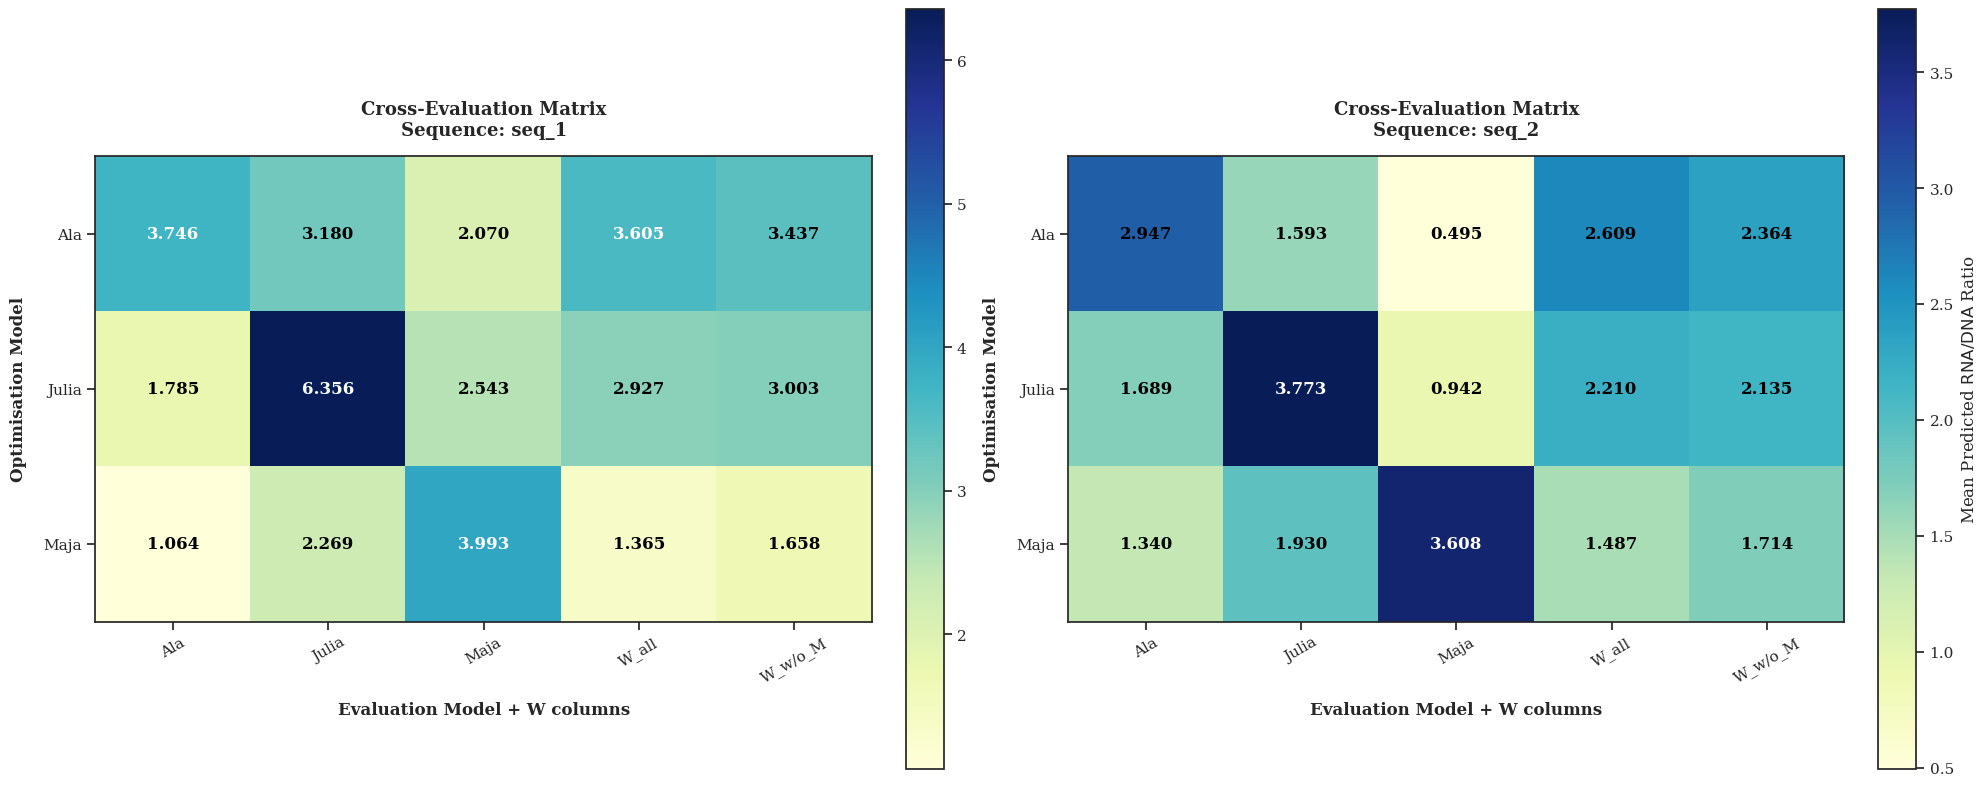

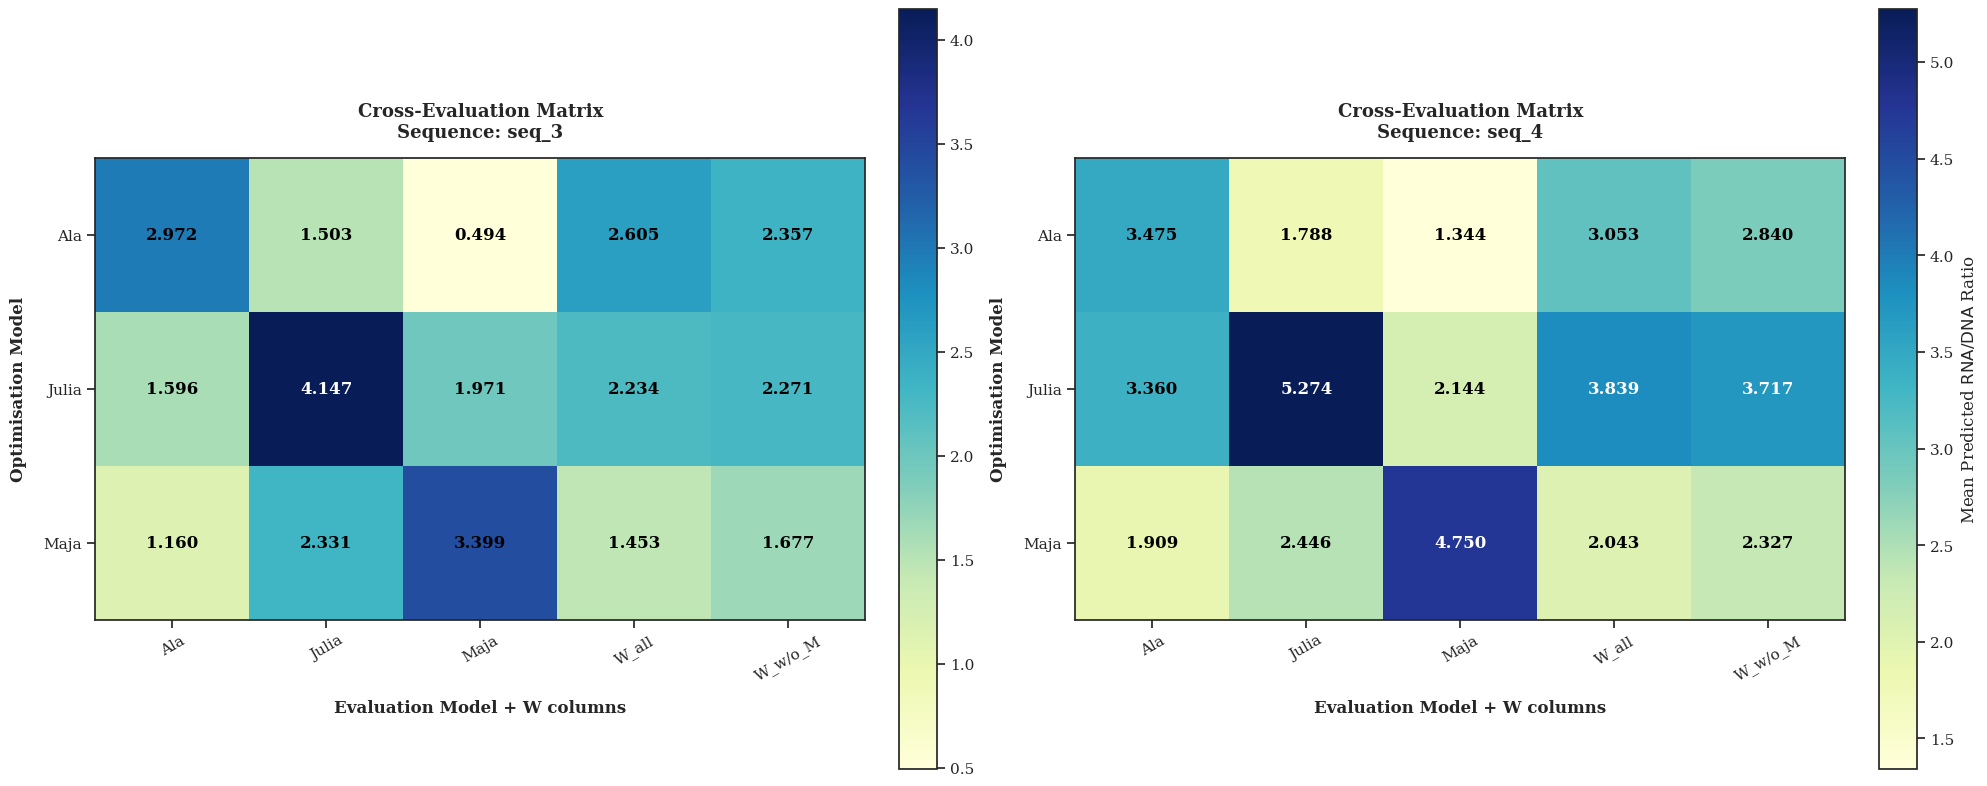

In [ ]:
weight_eval = pd.read_csv("weighted_sequence_evaluation.csv")

eval_cols = ["Ala", "Julia", "Maja"]
w_cols = ["W_all", "W_w/o_M"]
all_cols = eval_cols + w_cols

unique_sequences = weight_eval["seq_no"].unique()
n = len(unique_sequences)

for i in range(0, n, 2):
    seq_ids = unique_sequences[i : i + 2]
    num_in_row = len(seq_ids)

    fig, axes = plt.subplots(1, num_in_row, figsize=(20, 8))
    if num_in_row == 1:
        axes = [axes]

    for ax, sequence_id in zip(axes, seq_ids):
        sequence_df = weight_eval[weight_eval["seq_no"] == sequence_id]
        cross_eval = sequence_df.groupby("optimization_model")[all_cols].mean()
        row_order = eval_cols
        col_order = all_cols
        cross_eval = cross_eval.reindex(index=row_order, columns=col_order)

        sns.set_theme(style="ticks")
        plt.rcParams.update({
            "font.family": "serif",
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.titlesize": 13
        })
        im = ax.imshow(cross_eval.values, cmap="YlGnBu")

        if ax == axes[-1]:
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("Mean Predicted $\\text{RNA}/\\text{DNA}$ Ratio")
        else:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation="vertical")

        ax.set_xticks(np.arange(len(col_order)), labels=col_order)
        ax.set_yticks(np.arange(len(row_order)), labels=row_order)
        ax.set_xlabel("Evaluation Model + W columns", labelpad=12, weight="bold")
        ax.set_ylabel("Optimisation Model", labelpad=12, weight="bold")
        ax.set_title(f"Cross-Evaluation Matrix\nSequence: {sequence_id}", weight="bold", pad=15)

        for row in range(len(row_order)):
            for col in range(len(col_order)):
                val = cross_eval.iloc[row, col]
                ax.text(
                    col, row, f"{val:.3f}" if not pd.isna(val) else "",
                    ha="center", va="center",
                    color="white" if val >= 3.6 else "black", fontsize=12, fontweight="bold"

                )

        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    if num_in_row == 2:
        filename_part = f"{seq_ids[0]}_{seq_ids[1]}"
    else:
        filename_part = f"{seq_ids[0]}"
    out_dir = 'runs_stochastic/heatmaps'
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f"{out_dir}/cross_evaluation_heatmap_{filename_part}_with_W.png", dpi=300, bbox_inches="tight")
    plt.show()

from the maticies above we can observe that for the sequenes 1-3 the top sequences generated by model_A are to be chosen, whereas the 4th sequenece fares better when run by model_J

the baseline scores of the sequences

In [ ]:
baseline = []
a_model_path = FILE_PATH + "model_A.pth"

def run_evaluation(model_path, test_file, who):
    result = subprocess.run(
        ["python", f"evaluation_script_{who}.py", model_path, test_file],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("Error during evaluation:")
        print(result.stderr)
    else:
        output_lines = result.stdout.strip().split("\n")
        print(output_lines[0])
        if len(output_lines) > 1:
            print(output_lines[1])
    return output_lines[-1].split('\t')[-1]

for seq in range(1,5):
    baseline.append( run_evaluation(a_model_path, f'seq{seq}.fa', who='A'))


id	predicted_is_active	predicted_rna_dna_ratio
seq_1_broken	0	-0.095351
id	predicted_is_active	predicted_rna_dna_ratio
seq_2_broken	1	0.472369
id	predicted_is_active	predicted_rna_dna_ratio
seq_3_broken	1	0.073077
id	predicted_is_active	predicted_rna_dna_ratio
seq_4_no_active	0	-0.040987


In [ ]:
sequences = []

def get_top_sequence_for_seq_i(i, highest_vlaues, sequences, model="Ala"):
  # to maintain consistency the scores will be derived from the _A model
    file = highest_vlaues.loc[
        (highest_vlaues['seq_no'] == f'seq_{i}') &
        (highest_vlaues['optimization_model'] == model) &
        (highest_vlaues['eval_model'] == "Ala")
    ].sort_values(by='rna_dna_ratio', ascending=False).head(1)
    filename = file['filename'].values[0]
    eval_score = file['rna_dna_ratio'].values[0]
    print(f'seq_{i}, the file with the chosen sequence: ', filename)


    with open(f'./runs_stochastic/seq_{i}/{filename}') as f:
        last = f.readlines()[-1].split('\t')
        nr_mut = last[0]
        seq = last[2]
        print(' no of muntations: ', nr_mut)
        print(' sequence:', seq)
        print(f" score from evaluation model: {eval_score}")
        print(f' score at the beginning: {baseline[i-1]}')
        print(f'    change in score = {float(eval_score) - float(baseline[i-1])}')
        sequences.append(seq)
    return seq

for i in range(1,5):
    if i == 4:
        get_top_sequence_for_seq_i(i, highest_vlaues, sequences, model="Julia")
    else:
        get_top_sequence_for_seq_i(i, highest_vlaues, sequences)


seq_1, the file with the chosen sequence:  seq_1_broken_20260607_085851_iter40_win35_A.tsv
 no of muntations:  40
 sequence: ATGACTAATGAGTCACGTGATTGCACATTGATCAAAGTCCATTAGTTAATGTTTGCTGGGGCGGAGCTTCACAAGGTACATGGGAGGGAGGTCATAAGACTCATTGTCCAGAAGAAGAATGTCACAAGGTCAATCGATCCATTAAGGTAGGGCAGGGACCTTGTTAGCACGACCGTAAAGGGAATATTGATTAATCAGTTAAGGCCGGAAGTGGCAGTTGATCCGGTCCT
 score from evaluation model: 3.746232
 score at the beginning: -0.095351
    change in score = 3.841583
seq_2, the file with the chosen sequence:  seq_2_broken_20260607_094818_iter16_win36_A.tsv
 no of muntations:  15
 sequence: TCGGTTCACGCAATGACTAATTAATCATTAACAATCATTAACTCCTTCGACCAATCAAACTCCCCTTCCCCCCGTCATGTCAACAAGGAATGACATCAATAATGTCTTAGCAAACAAGGAAGCCAATAATCCAGTCTCATGATTAAAAACCTGAAAACCTTGACCATAAAAGAACCTTTGCATTGGCCGAGTGCGGTGGCTCATGCCTGTAATCCAGTTGATCCGGTCCT
 score from evaluation model: 2.947463
 score at the beginning: 0.472369
    change in score = 2.475094
seq_3, the file with the chosen sequence:  seq_3_broken_20260607_105858_iter20_

Even when manually tweaking the sequences with what we thought would be a more benefitial single point mutation (based on the data from the plots), the score never rose so much so that is decreased each time.

For our models these are the sequences that were ultimately chosen.